<a href="https://colab.research.google.com/github/adilyarizkim/portofolio/blob/Portofolio/Digital_Research_TMIIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
    from google.colab import drive
    import pandas as pd
    import re

    drive.mount('/content/drive')
    file_path = '/content/drive/My Drive/TMMINdata2.xlsx'


    xls = pd.ExcelFile(file_path)

Mounted at /content/drive


In [ ]:


    df = pd.read_excel(file_path, header=0)
    print(df.columns)


Index(['service', 'date', 'time', 'title', 'datetime', 'follower',
       'engagement', 'comments', 'likes', 'shares', 'views', 'user_id',
       'username', 'name', 'user created at', 'post type', 'media type',
       'tags', 'gender', 'sentiment', 'image', 'message', 'url', 'in reply to',
       'in reply to_user', 'post provinsi name', 'post kabupdaten name',
       'post provinsi coordinate lot', 'post provinsi coordinate lan',
       'post kabupaten coordinate lot', 'post kabupaten coordinate lan',
       'user provinsi name', 'user kabupaten name',
       'user provinsi coordinate lat', 'user provinsi coordinate lon',
       'user kabupaten coordinate lat', 'user kabupaten coordinate lon',
       'journalist', 'media tier', 'news value', 'ad value', 'content_type'],
      dtype='object')


In [ ]:
mapping_toyota = {
    "Veloz": ["veloz", "all new veloz", "veloz terbaru"],
    "Yaris Hatchback": ["yarishb","yaris hb","yarishatchback", "yaris hatchback"],
    "Yaris Cross": ["yaris cross", "yariscross", "yaris cross hybrid", "yaris cross gr sport", "all new yaris cross", "yaris cross 2024"],
    "Fortuner": ["fortuner"],
    "Kijang Innova": ["kijanginnova", "kijang innova", "innovareborn", "innova reborn"],
    "Kijang Innova Zenix": ["kijanginnovazenix", "kijang innova zenix", "innova zenix", "innovazenix", "innova zenix hybrid"]
}

In [ ]:
 use_categories_gaya = {
        "Gaya Hidup Keluarga dan Praktis": [
            "keluarga besar", "mobil keluarga", "nyaman untuk anak", "antar jemput sekolah",
            "liburan keluarga", "cocok untuk mudik", "tempat duduk banyak"
        ],
        "Gaya Hidup Aktif dan Petualang": [
            "off-road", "petualangan", "jalan terjal", "kuat di medan berat", "tangguh", "sport utility vehicle",
            "suv", "adventure", "cocok untuk alam", "mobil tangguh", "kendaraan outdoor"
        ],
        "Gaya Hidup Urban dan Modern": [
            "mobil compact", "hemat bahan bakar", "stylish", "mudah parkir", "mobil kota", "efisien",
            "trendy", "desain modern", "praktis", "nyaman dikendarai", "ringan", "cocok untuk milenial", "genz", "gen z"
        ],
        "Gaya Hidup Profesional dan Eksklusif": [
            "mobil mewah", "executive car", "fitur lengkap", "prestige", "kabin mewah",
            "teknologi canggih", "mobil bisnis", "mobil vip", "elegan", "eksklusif", "high class", "kemewahan"
        ],
        "Gaya Hidup Bisnis dan Fungsional": [
            "mobil bisnis", "angkut barang", "pick up", "kendaraan niaga", "muatan besar", "tahan banting",
            "kendaraan usaha", "distribusi barang", "jasa pengiriman", "efisiensi operasional", "kendaraan komersial",
            "kendaraan kerja"
        ]
    }


In [ ]:
# 4️⃣ Function: Mapping Brand (safe version)
def map_brand(text):
    if pd.isnull(text):  # cek kalau text kosong/NaN
        return "Other"
    text_lower = str(text).lower()
    for brand, keywords in mapping_toyota.items():
        for keyword in keywords:
            if keyword in text_lower:
                return brand
    return "Other"

# 5️⃣ Function: Mapping Gaya Hidup (safe version)
def map_gaya(text):
    if pd.isnull(text):  # cek kalau text kosong/NaN
        return "Other"
    text_lower = str(text).lower()
    for category, keywords in use_categories_gaya.items():
        for keyword in keywords:
            if keyword in text_lower:
                return category
    return "Other"


In [ ]:
# Apply ke DataFrame
df['Mapped Brand'] = df['message'].apply(map_brand)
df['Gaya Hidup'] = df['message'].apply(map_gaya)


In [ ]:
pivot_table = pd.pivot_table(
    df,
    index='Mapped Brand',
    columns='Gaya Hidup',
    values='message',
    aggfunc='count',
    fill_value=0
)

# Print Pivot (untuk dicek di output)
print(pivot_table)

# Export ke CSV
pivot_table.to_csv('pivot_brand_gaya.csv')

print("✅ Pivot table berhasil diexport ke 'pivot_brand_gaya.csv'")

Gaya Hidup           Gaya Hidup Aktif dan Petualang  \
Mapped Brand                                          
Fortuner                                        225   
Kijang Innova                                    20   
Kijang Innova Zenix                              18   
Other                                          1713   
Veloz                                            31   
Yaris Cross                                      37   
Yaris Hatchback                                   0   

Gaya Hidup           Gaya Hidup Bisnis dan Fungsional  \
Mapped Brand                                            
Fortuner                                           17   
Kijang Innova                                       1   
Kijang Innova Zenix                                 1   
Other                                             222   
Veloz                                               7   
Yaris Cross                                         0   
Yaris Hatchback                                 

In [ ]:
# Buat Pivot Table
pivot_table = pd.pivot_table(
    df,
    index='Mapped Brand',
    columns='Gaya Hidup',
    values='message',
    aggfunc='count',
    fill_value=0
)

# Tampilkan tabel ke output
import pandas as pd
from IPython.display import display

display(pivot_table)


Gaya Hidup,Gaya Hidup Aktif dan Petualang,Gaya Hidup Bisnis dan Fungsional,Gaya Hidup Keluarga dan Praktis,Gaya Hidup Profesional dan Eksklusif,Gaya Hidup Urban dan Modern,Other
Mapped Brand,,,,,,
Fortuner,225,17,22,34,56,5838
Kijang Innova,20,1,17,23,54,2023
Kijang Innova Zenix,18,1,33,81,48,1593
Other,1713,222,283,487,1012,120404
Veloz,31,7,15,37,140,2215
Yaris Cross,37,0,6,8,27,596
Yaris Hatchback,0,0,0,0,0,3


In [ ]:
# Pivot Brand x Gender
pivot_brand_gender = pd.pivot_table(
    df,
    index='Mapped Brand',
    columns='gender',
    values='message',
    aggfunc='count',
    fill_value=0
)

print("Pivot: Brand x Gender")
display(pivot_brand_gender)


Pivot: Brand x Gender


gender,-,Female,Male
Mapped Brand,,,
Fortuner,0,707,2138
Kijang Innova,0,180,821
Kijang Innova Zenix,0,164,726
Other,5,15177,51706
Veloz,0,364,1237
Yaris Cross,0,49,256
Yaris Hatchback,0,2,1


In [ ]:
# Pivot Brand x Gaya Hidup x Gender (multi-index)
pivot_brand_gaya_gender = pd.pivot_table(
    df,
    index='Mapped Brand',
    columns=['Gaya Hidup', 'gender'],
    values='message',
    aggfunc='count',
    fill_value=0
)

print("Pivot: Brand x Gaya Hidup x Gender")
display(pivot_brand_gaya_gender)


Pivot: Brand x Gaya Hidup x Gender


Gaya Hidup          Gaya Hidup Aktif dan Petualang              \
gender                                           - Female Male   
Mapped Brand                                                     
Fortuner                                         0     18   68   
Kijang Innova                                    0      0   11   
Kijang Innova Zenix                              0      3   10   
Other                                            1    249  792   
Veloz                                            0      9   10   
Yaris Cross                                      0      2    7   
Yaris Hatchback                                  0      0    0   

Gaya Hidup          Gaya Hidup Bisnis dan Fungsional       \
gender                                        Female Male   
Mapped Brand                                                
Fortuner                                           0   10   
Kijang Innova                                      0    0   
Kijang Innova Zenix                                0    0   
Other                                             33   82   
Veloz                                              0    1   
Yaris Cross                                        0    0   
Yaris Hatchback                                    0    0   

Gaya Hidup          Gaya Hidup Keluarga dan Praktis       \
gender                                       Female Male   
Mapped Brand                                               
Fortuner                                          6   12   
Kijang Innova                                     2    2   
Kijang Innova Zenix                               3   23   
Other                                            40  111   
Veloz                                             0    4   
Yaris Cross                                       1    5   
Yaris Hatchback                                   0    0   

Gaya Hidup          Gaya Hidup Profesional dan Eksklusif       \
gender                                            Female Male   
Mapped Brand                                                    
Fortuner                                               3   16   
Kijang Innova                                          0   10   
Kijang Innova Zenix                                    3   40   
Other                                                 53  238   
Veloz                                                  4   22   
Yaris Cross                                            3    3   
Yaris Hatchback                                        0    0   

Gaya Hidup          Gaya Hidup Urban dan Modern      Other                
gender                                   Female Male     - Female   Male  
Mapped Brand                                                              
Fortuner                                      2   40     0    678   1992  
Kijang Innova                                 2   28     0    176    770  
Kijang Innova Zenix                           3   20     0    152    633  
Other                                       143  525     4  14659  49958  
Veloz                                        22   85     0    329   1115  
Yaris Cross                                   2   16     0     41    225  
Yaris Hatchback                               0    0     0      2      1

In [ ]:
# Import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan pivot_table sudah ada → contoh pivot dari yang Anda tampilkan
pivot_table = pd.DataFrame({
    'Gaya Hidup Aktif dan Petualang': [225, 20, 18, 31, 37, 0],
    'Gaya Hidup Bisnis dan Fungsional': [17, 1, 1, 7, 0, 0],
    'Gaya Hidup Keluarga dan Praktis': [22, 17, 33, 15, 6, 0],
    'Gaya Hidup Profesional dan Eksklusif': [34, 23, 81, 37, 8, 0],
    'Gaya Hidup Urban dan Modern': [56, 54, 48, 140, 27, 0]
},
index=['Fortuner', 'Kijang Innova', 'Kijang Innova Zenix', 'Veloz', 'Yaris Cross', 'Yaris Hatchback'])


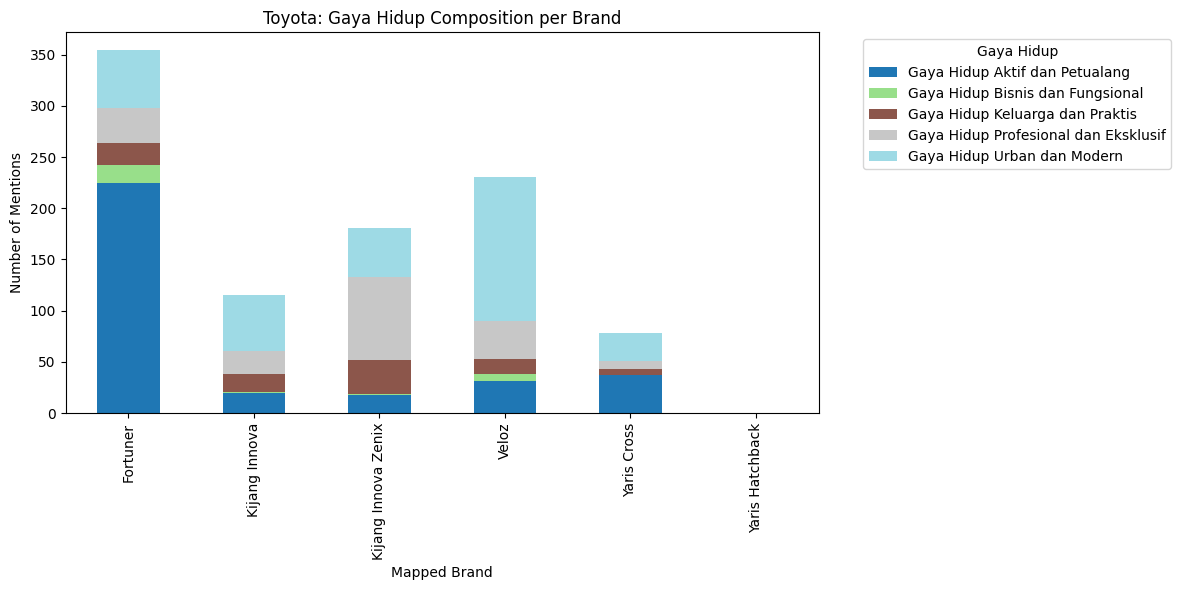

In [ ]:
# Plot: Stacked Bar Chart
pivot_table.plot(kind='bar', stacked=True, figsize=(12,6), colormap='tab20')

plt.title('Toyota: Gaya Hidup Composition per Brand')
plt.ylabel('Number of Mentions')
plt.xlabel('Mapped Brand')
plt.legend(title='Gaya Hidup', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
mapping_toyota = {
    "Veloz": ["veloz", "all new veloz", "veloz terbaru"],
    "Yaris Hatchback": ["yarishb","yaris hb","yarishatchback", "yaris hatchback"],
    "Yaris Cross": ["yaris cross", "yariscross", "yaris cross hybrid", "yaris cross gr sport", "all new yaris cross", "yaris cross 2024"],
    "Fortuner": ["fortuner"],
    "Kijang Innova": ["kijanginnova", "kijang innova", "innovareborn", "innova reborn"],
    "Kijang Innova Zenix": ["kijanginnovazenix", "kijang innova zenix", "innova zenix", "innovazenix", "innova zenix hybrid"]
}

mapping_kompetitor = {
    "Xpander": ["xpander"],
    "Stargazer": ["stargazer"],
    "Cortez": ["cortez", "wulingcortez", "wuling cortez"],
    "Confero": ["confero", "wulingconfero", "wuling confero"],
    "Ertiga": ["ertiga", "suzukiertiga", "suzuki ertiga"],
    "HR-V": ["hrv", "hr-v", "honda hrv", "honda hr-v"],
    "Creta": ["creta", "hyundaicreta", "hyundai creta"],
    "Alvez": ["alvez", "wulingalvez", "wuling alvez"]
}

# Compile regex patterns for faster matching
compiled_patterns = []

# Toyota
for brand, keywords in mapping_toyota.items():
    for kw in sorted(keywords, key=len, reverse=True):
        # Use word boundaries to ensure whole word matching
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_patterns.append(('Toyota', brand, pattern))

# Kompetitor
for brand, keywords in mapping_kompetitor.items():
    for kw in sorted(keywords, key=len, reverse=True):
        # Use word boundaries to ensure whole word matching
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_patterns.append(('Kompetitor', brand, pattern))

# Define the fast_match function to apply to the message column
def fast_match(message):
    # Clean the message: convert to lowercase, remove non-alphanumeric characters except spaces, and strip whitespace
    message_clean = re.sub(r'[^\w\s]', ' ', str(message).lower()).strip()

    # Iterate through compiled patterns and return the first match
    for group, brand, pattern in compiled_patterns:
        if pattern.search(message_clean):
            return pd.Series([group, brand])

    # Return None if no match is found
    return pd.Series([None, None])

# Apply the fast_match function to the 'message' column and create new columns
df[['Matched Group', 'Matched Brand']] = df['message'].apply(fast_match)

# Filter for rows where a match was found
df_matched = df[df['Matched Group'].notnull()]

# --- PIVOT TOYOTA ---
# Filter for Toyota matches and group by 'Matched Brand' to count messages
df_toyota = df_matched[df_matched['Matched Group'] == 'Toyota']
pivot_toyota = df_toyota.groupby('Matched Brand').size().reset_index(name='Jumlah Message').set_index('Matched Brand')

# --- PIVOT KOMPETITOR ---
# Filter for Kompetitor matches and group by 'Matched Brand' to count messages
df_kompetitor = df_matched[df_matched['Matched Group'] == 'Kompetitor']
pivot_kompetitor = df_kompetitor.groupby('Matched Brand').size().reset_index(name='Jumlah Message').set_index('Matched Brand')

# Display the pivot tables
print("\n=== PIVOT TOYOTA ===")
display(pivot_toyota)

print("\n=== PIVOT KOMPETITOR ===")
display(pivot_kompetitor)


=== PIVOT TOYOTA ===


,Jumlah Message
Matched Brand,
Fortuner,6109
Kijang Innova,2175
Kijang Innova Zenix,1770
Veloz,2311
Yaris Cross,692
Yaris Hatchback,3



=== PIVOT KOMPETITOR ===


,Jumlah Message
Matched Brand,
Alvez,2094
Confero,828
Cortez,1191
Creta,1232
Ertiga,3155
HR-V,664
Stargazer,722
Xpander,2271


In [ ]:
df['date'] = pd.to_datetime(df['date'])

# Define the Toyota mapping (as before)
mapping_toyota = {
    "Veloz": ["veloz", "all new veloz", "veloz terbaru"],
    "Yaris Hatchback": ["yarishb", "yaris hb", "yarishatchback", "yaris hatchback"],
    "Yaris Cross": ["yaris cross", "yariscross", "yaris cross hybrid", "yaris cross gr sport", "all new yaris cross", "yaris cross 2024"],
    "Fortuner": ["fortuner"],
    "Kijang Innova": ["kijanginnova", "kijang innova", "innovareborn", "innova reborn"],
    "Kijang Innova Zenix": ["kijanginnovazenix", "kijang innova zenix", "innova zenix", "innovazenix", "innova zenix hybrid"]
}

# Compile regex patterns for faster matching
compiled_patterns_toyota = []

# Toyota
for brand, keywords in mapping_toyota.items():
    for kw in sorted(keywords, key=len, reverse=True):
        # Use word boundaries to ensure whole word matching
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_patterns_toyota.append(('Toyota', brand, pattern))

# Define the fast_match function to apply to the message column for Toyota brands
def fast_match_toyota(message):
    # Clean the message: convert to lowercase, remove non-alphanumeric characters except spaces, and strip whitespace
    message_clean = re.sub(r'[^\w\s]', ' ', str(message).lower()).strip()

    # Iterate through compiled patterns and return the first match
    for group, brand, pattern in compiled_patterns_toyota:
        if pattern.search(message_clean):
            return pd.Series([group, brand])

    # Return None if no match is found
    return pd.Series([None, None])

# Apply the fast_match function to the 'message' column and create new columns for matched group and brand
df[['Matched Group', 'Matched Brand']] = df['message'].apply(fast_match_toyota)

# Filter for rows where a match was found
df_matched_toyota = df[df['Matched Group'].notnull()]

# Extract the year and month from the 'date' column for grouping using .loc to avoid warnings
df_matched_toyota.loc[:, 'Year-Month'] = df_matched_toyota['date'].dt.to_period('M')

# Group by 'service', 'Year-Month', and 'Matched Brand' to count messages
pivot_toyota_service = df_matched_toyota.groupby(['service', 'Year-Month', 'Matched Brand']).size().reset_index(name='Jumlah Message')

# Pivot table to show messages per service, month, and Toyota model
pivot_toyota_service = pivot_toyota_service.pivot_table(index=['service', 'Year-Month'], columns='Matched Brand', values='Jumlah Message', aggfunc='sum', fill_value=0)

# Display the pivot table
display(pivot_toyota_service)

print("\n=== PIVOT TOYOTA PER SERVICE AND MONTH ===")
print(pivot_toyota_service)

<ipython-input-10-7c0a2f6a851d>:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matched_toyota.loc[:, 'Year-Month'] = df_matched_toyota['date'].dt.to_period('M')


Matched Brand         Fortuner  Kijang Innova  Kijang Innova Zenix  Veloz  \
service   Year-Month                                                        
facebook  2024-08           19              2                    2      3   
          2024-09           23              8                    2      4   
          2024-10            6              0                    0      6   
          2024-11           10              5                    0      4   
          2024-12           12              8                    3      6   
          2025-01           28              8                    2      7   
          2025-02           52             13                    6     35   
instagram 2024-07           10              4                    0      1   
          2024-08           20             33                   66    199   
          2024-09           28             68                  107    219   
          2024-10           13             19                   70     38   
          2024-11           27             67                   82     86   
          2024-12           23            140                  100    256   
          2025-01           41             72                   72    191   
          2025-02          191             56                   95    215   
tiktok    2024-07           18             13                    5     10   
          2024-08           20             12                    6     27   
          2024-09           76             13                   13     15   
          2024-10           78             20                    7     24   
          2024-11           52             20                    8     39   
          2024-12           57             17                   15     28   
          2025-01           98             36                   23     67   
          2025-02           98             30                   30     92   
twitter   2024-07          613            139                   47     57   
          2024-08          448             80                   25     44   
          2024-09          726            474                  624     70   
          2024-10          463            122                   37     51   
          2024-11          405            110                   31     49   
          2024-12          573            143                   29     51   
          2025-01          882            148                   34     69   
          2025-02          370             86                  116     47   
youtube   2024-07           31             13                   11     41   
          2024-08           26             28                   16     24   
          2024-09          217             23                   20     42   
          2024-10           53             22                   14     46   
          2024-11           81             22                   14     30   
          2024-12           80             16                   12     32   
          2025-01           77             49                   11     49   
          2025-02           64             36                   15     37   

Matched Brand         Yaris Cross  Yaris Hatchback  
service   Year-Month                                
facebook  2024-08               0                0  
          2024-09               0                0  
          2024-10               0                0  
          2024-11               0                0  
          2024-12               2                0  
          2025-01               0                0  
          2025-02               0                0  
instagram 2024-07               0                0  
          2024-08              20                0  
          2024-09              30                0  
          2024-10               0                0  
          2024-11              18                0  
          2024-12              32                0  
          2025-01              24              


=== PIVOT TOYOTA PER SERVICE AND MONTH ===
Matched Brand         Fortuner  Kijang Innova  Kijang Innova Zenix  Veloz  \
service   Year-Month                                                        
facebook  2024-08           19              2                    2      3   
          2024-09           23              8                    2      4   
          2024-10            6              0                    0      6   
          2024-11           10              5                    0      4   
          2024-12           12              8                    3      6   
          2025-01           28              8                    2      7   
          2025-02           52             13                    6     35   
instagram 2024-07           10              4                    0      1   
          2024-08           20             33                   66    199   
          2024-09           28             68                  107    219   
          2024-10           13  

In [ ]:
# Define the Competitor mapping (as before)
mapping_kompetitor = {
    "Xpander": ["xpander"],
    "Stargazer": ["stargazer"],
    "Cortez": ["cortez", "wulingcortez", "wuling cortez"],
    "Confero": ["confero", "wulingconfero", "wuling confero"],
    "Ertiga": ["ertiga", "suzukiertiga", "suzuki ertiga"],
    "HR-V": ["hrv", "hr-v", "honda hrv", "honda hr-v"],
    "Creta": ["creta", "hyundaicreta", "hyundai creta"],
    "Alvez": ["alvez", "wulingalvez", "wuling alvez"]
}

# Compile regex patterns for faster matching for competitors
compiled_patterns_kompetitor = []

# Competitors
for brand, keywords in mapping_kompetitor.items():
    for kw in sorted(keywords, key=len, reverse=True):
        # Use word boundaries to ensure whole word matching
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_patterns_kompetitor.append(('Kompetitor', brand, pattern))

# Define the fast_match function to apply to the message column for Competitor brands
def fast_match_kompetitor(message):
    # Clean the message: convert to lowercase, remove non-alphanumeric characters except spaces, and strip whitespace
    message_clean = re.sub(r'[^\w\s]', ' ', str(message).lower()).strip()

    # Iterate through compiled patterns and return the first match
    for group, brand, pattern in compiled_patterns_kompetitor:
        if pattern.search(message_clean):
            return pd.Series([group, brand])

    # Return None if no match is found
    return pd.Series([None, None])

# Apply the fast_match function to the 'message' column and create new columns for matched group and brand
df[['Matched Group', 'Matched Brand']] = df['message'].apply(fast_match_kompetitor)

# Filter for rows where a match was found
df_matched_kompetitor = df[df['Matched Group'].notnull()]

# Extract the year and month from the 'date' column for grouping using .loc to avoid warnings
df_matched_kompetitor.loc[:, 'Year-Month'] = df_matched_kompetitor['date'].dt.to_period('M')

# Group by 'service', 'Year-Month', and 'Matched Brand' to count messages
pivot_kompetitor_service = df_matched_kompetitor.groupby(['service', 'Year-Month', 'Matched Brand']).size().reset_index(name='Jumlah Message')

# Pivot table to show messages per service, month, and Competitor model
pivot_kompetitor_service = pivot_kompetitor_service.pivot_table(index=['service', 'Year-Month'], columns='Matched Brand', values='Jumlah Message', aggfunc='sum', fill_value=0)

# Display the pivot table
display(pivot_kompetitor_service)

print("\n=== PIVOT KOMPETITOR PER SERVICE AND MONTH ===")
print(pivot_kompetitor_service)


<ipython-input-11-4fbabca8b5cd>:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matched_kompetitor.loc[:, 'Year-Month'] = df_matched_kompetitor['date'].dt.to_period('M')


Matched Brand         Alvez  Confero  Cortez  Creta  Ertiga  HR-V  Stargazer  \
service   Year-Month                                                           
facebook  2024-08         0        1       0      0       3     0          0   
          2024-09         0        0       0      0       2     1          0   
          2024-10         0        0       0      0       1     2          0   
          2024-11         0        0       0      0       1     7          0   
          2024-12         0        0       0      0       1     1          0   
          2025-01         0        8       5      0       5    13          0   
          2025-02         0       30      54      0       9     4          0   
instagram 2024-07         0       12      40      0       0     0          0   
          2024-08        32       47      86      0       2     2          9   
          2024-09        54       39      72      0       4     0          2   
          2024-10        34       24      37      0       1     2          3   
          2024-11       158       33      85      0       9     3          0   
          2024-12       107       64     143      0      94     7          3   
          2025-01       143       73     120      3     154    22          2   
          2025-02       199       52      97      0     682    11          4   
tiktok    2024-07         7        4       4     45       7    24         10   
          2024-08         3        7       3     17       5    20          6   
          2024-09         6        0       0     15      41    17          9   
          2024-10        10        8       5     30      32    29         21   
          2024-11         7       11       5     66      13    34          6   
          2024-12        15        5       5     23      22    13         11   
          2025-01        18       28       8    153      25    82         14   
          2025-02        23       22       9     43     101    24         47   
twitter   2024-07        65       22      42     68     276    22         66   
          2024-08        54       12      24     49     150    17         37   
          2024-09       226       15      45     99     248    58         81   
          2024-10       204       35      21     59     309    30         47   
          2024-11       109        6      22     49     209    33         25   
          2024-12       278       55      39    170     249    38         42   
          2025-01       141       18      80    180     344    27         71   
          2025-02        71        9      12     34     120    12         25   
youtube   2024-07        17       33      34      7      32     5         39   
          2024-08        15       27      17      1      14    42         21   
          2024-09         9       11       4      4      17    39         12   
          2024-10        18       30       3     15       9    36         31   
          2024-11        11       22      27      2      36    29         19   
          2024-12        17       30      16      9      16    19         18   
          2025-01        30       36      26     89      32    51         41   
          2025-02        13       28      21     28      26    23         32   

Matched Brand         Xpander  
service   Year-Month           
facebook  2024-08           7  
          2024-09           4  
          2024-10           0  
          2024-11           2  
          2024-12           3  
          2025-01           5  
          2025-02          27  
instagram 2024-07           0  
          2024-08          11  
          2024-09           6  
          2024-10           2  
          2024-11          21  
          2024-12          13  
          2025-01          35  
          2025-02          93  
tiktok    2024-07          36  
          2024-08           9  
          2024-09          38  
          2024-10          30  
          2024-11          19  
          2024-


=== PIVOT KOMPETITOR PER SERVICE AND MONTH ===
Matched Brand         Alvez  Confero  Cortez  Creta  Ertiga  HR-V  Stargazer  \
service   Year-Month                                                           
facebook  2024-08         0        1       0      0       3     0          0   
          2024-09         0        0       0      0       2     1          0   
          2024-10         0        0       0      0       1     2          0   
          2024-11         0        0       0      0       1     7          0   
          2024-12         0        0       0      0       1     1          0   
          2025-01         0        8       5      0       5    13          0   
          2025-02         0       30      54      0       9     4          0   
instagram 2024-07         0       12      40      0       0     0          0   
          2024-08        32       47      86      0       2     2          9   
          2024-09        54       39      72      0       4     0       

=====================================================================================


In [ ]:


# Ensure 'date' is in datetime format
df['date'] = pd.to_datetime(df['date'])

# Define new mappings for People and Goods needs
mapping_people_goods = {
    'Wellness': {
        'category': 'People',
        'keywords': ['Mobil Kesehatan', 'Aksesibilitas', 'Transportasi Medis', 'Ambulans', 'ambulan', 'Klinik Mobil', 'Wellcab']
    },
    'Leisure': {
        'category': 'People',
        'keywords': ['Kendaraan Perjalanan', 'Campervan', 'Van Mewah', 'Van Karaoke', 'Petualangan', 'Camper', 'van']
    },
    'Commercial': {
        'category': 'People',
        'keywords': ['Transportasi Bisnis', 'Solusi Penumpang', 'Taksi', 'Ride Hailing', 'Transportasi Korporasi', 'Jaklingko', 'Angkutan Kota', 'Angkot', 'Transjakarta', 'busway']
    },
    'Logistic': {
        'category': 'Goods',
        'keywords': ['Transportasi Aman', 'Penanganan Khusus', 'Cold Chain', 'Kendaraan Pos', 'Kendaraan Pengiriman', 'logistik']
    },
    'Store': {
        'category': 'Goods',
        'keywords': ['Food Truck', 'Mobile Shop', 'Layanan Ritel', 'Toko Bergerak', 'F&B Services']
    },
    'Service': {
        'category': 'Goods',
        'keywords': ['ATM Mobile', 'Kendaraan Layanan Publik', 'Mobil Layanan', 'Layanan On-the-Go', 'layanan keliling', 'keliling', 'service keliling']
    }
}

# Compile regex patterns for faster matching
compiled_patterns_people_goods = []

# People and Goods
for category, details in mapping_people_goods.items():
    for kw in sorted(details['keywords'], key=len, reverse=True):
        # Use word boundaries to ensure whole word matching
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_patterns_people_goods.append((details['category'], category, pattern))

# Define the fast_match function to apply to the message column for People and Goods categories
def fast_match_people_goods(message):
    # Clean the message: convert to lowercase, remove non-alphanumeric characters except spaces, and strip whitespace
    message_clean = re.sub(r'[^\w\s]', ' ', str(message).lower()).strip()

    # Iterate through compiled patterns and return the first match
    for category, subcategory, pattern in compiled_patterns_people_goods:
        if pattern.search(message_clean):
            return pd.Series([category, subcategory])

    # Return None if no match is found
    return pd.Series([None, None])

# Apply the fast_match function to the 'message' column and create new columns for matched category and subcategory
df[['Matched Category', 'Matched Subcategory']] = df['message'].apply(fast_match_people_goods)

# Filter for rows where a match was found
df_matched_people_goods = df[df['Matched Category'].notnull()]

# Extract the year and month from the 'date' column for grouping using .loc to avoid warnings
df_matched_people_goods.loc[:, 'Year-Month'] = df_matched_people_goods['date'].dt.to_period('M')

# Group by 'service', 'Year-Month', and 'Matched Subcategory' to count messages
pivot_people_goods_service = df_matched_people_goods.groupby(['service', 'Year-Month', 'Matched Subcategory']).size().reset_index(name='Jumlah Message')

# Pivot table to show messages per service, month, and category/subcategory
pivot_people_goods_service = pivot_people_goods_service.pivot_table(index=['service', 'Year-Month'], columns='Matched Subcategory', values='Jumlah Message', aggfunc='sum', fill_value=0)

# Display the pivot table
display(pivot_people_goods_service)

print("\n=== PIVOT PEOPLE AND GOODS PER SERVICE AND MONTH ===")
print(pivot_people_goods_service)


<ipython-input-13-12dee95a8cdc>:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matched_people_goods.loc[:, 'Year-Month'] = df_matched_people_goods['date'].dt.to_period('M')


Matched Subcategory   Commercial  Leisure  Logistic  Service  Wellness
service   Year-Month                                                  
facebook  2025-01              0        0         1        0         0
          2025-02              0        0         1        0         0
instagram 2024-08              0        1         6        2         0
          2024-09              0        1         2       26         0
          2024-10              0        1         2        2         1
          2024-12              0        2         3        2         0
          2025-01              0       11        17        9         4
          2025-02              0       14         8        4        47
tiktok    2024-07              0       11         0        6         0
          2024-08              0        5         0       19         1
          2024-09              0       11         1       17         0
          2024-10              0       14         0       20         1
          2024-11              0       15         0       10         0
          2024-12              0       13         0        7         0
          2025-01              1       19         0       18         1
          2025-02              0        9         0        4         0
twitter   2024-07              4        4         0       10         2
          2024-08              1        2         0        9         9
          2024-09              2        2         0       21         3
          2024-10              3        3         0       21         1
          2024-11              0        4         0       10         0
          2024-12              0        2         0       11         2
          2025-01              1        2         0        7         0
          2025-02              1        0         1        5         3
youtube   2024-07              0        3         0        7         0
          2024-08              0        2         0        5         0
          2024-09              0        7         1        3         1
          2024-10              0        4         0       22         2
          2024-11              0        6         1       28         0
          2024-12              0       18         2       37         0
          2025-01              0       24         1       22         0
          2025-02              0        4         1       19         0


=== PIVOT PEOPLE AND GOODS PER SERVICE AND MONTH ===
Matched Subcategory   Commercial  Leisure  Logistic  Service  Wellness
service   Year-Month                                                  
facebook  2025-01              0        0         1        0         0
          2025-02              0        0         1        0         0
instagram 2024-08              0        1         6        2         0
          2024-09              0        1         2       26         0
          2024-10              0        1         2        2         1
          2024-12              0        2         3        2         0
          2025-01              0       11        17        9         4
          2025-02              0       14         8        4        47
tiktok    2024-07              0       11         0        6         0
          2024-08              0        5         0       19         1
          2024-09              0       11         1       17         0
          2024-10      

In [ ]:
# Compile regex patterns for faster matching
compiled_patterns_people_goods = []

# People and Goods
for category, details in mapping_people_goods.items():
    for kw in sorted(details['keywords'], key=len, reverse=True):
        # Use word boundaries to ensure whole word matching
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_patterns_people_goods.append((details['category'], category, pattern))

# Define the fast_match function to apply to the message column for People and Goods categories
def fast_match_people_goods(message):
    # Clean the message: convert to lowercase, remove non-alphanumeric characters except spaces, and strip whitespace
    message_clean = re.sub(r'[^\w\s]', ' ', str(message).lower()).strip()

    # Iterate through compiled patterns and return the first match
    for category, subcategory, pattern in compiled_patterns_people_goods:
        if pattern.search(message_clean):
            return pd.Series([category, subcategory])

    # Return None if no match is found
    return pd.Series([None, None])

# Apply the fast_match function to the 'message' column and create new columns for matched category and subcategory
df[['Matched Category', 'Matched Subcategory']] = df['message'].apply(fast_match_people_goods)

# Filter for rows where a match was found
df_matched_people_goods = df[df['Matched Category'].notnull()]

# Extract the year and month from the 'date' column for grouping using .loc to avoid warnings
df_matched_people_goods.loc[:, 'Year-Month'] = df_matched_people_goods['date'].dt.to_period('M')

# Group by 'Year-Month' and 'Matched Subcategory' to count messages
pivot_people_goods_month = df_matched_people_goods.groupby(['Year-Month', 'Matched Subcategory']).size().reset_index(name='Jumlah Message')

# Pivot table to show messages per month and category/subcategory
pivot_people_goods_month = pivot_people_goods_month.pivot_table(index='Year-Month', columns='Matched Subcategory', values='Jumlah Message', aggfunc='sum', fill_value=0)

# Add total row per category/subcategory
pivot_people_goods_month['Total'] = pivot_people_goods_month.sum(axis=1)

# Add total column per subcategory
pivot_people_goods_month.loc['Total'] = pivot_people_goods_month.sum()

# Display the pivot table
display(pivot_people_goods_month)

print("\n=== PIVOT PEOPLE AND GOODS PER MONTH WITH TOTALS ===")
print(pivot_people_goods_month)

<ipython-input-14-70ac71c93fcc>:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matched_people_goods.loc[:, 'Year-Month'] = df_matched_people_goods['date'].dt.to_period('M')


Matched Subcategory,Commercial,Leisure,Logistic,Service,Wellness,Total
Year-Month,,,,,,
2024-07,4,18,0,23,2,47
2024-08,1,10,6,35,10,62
2024-09,2,21,4,67,4,98
2024-10,3,22,2,65,5,97
2024-11,0,25,1,48,0,74
2024-12,0,35,5,57,2,99
2025-01,2,56,19,56,5,138
2025-02,1,27,11,32,50,121
Total,13,214,48,383,78,736



=== PIVOT PEOPLE AND GOODS PER MONTH WITH TOTALS ===
Matched Subcategory  Commercial  Leisure  Logistic  Service  Wellness  Total
Year-Month                                                                  
2024-07                       4       18         0       23         2     47
2024-08                       1       10         6       35        10     62
2024-09                       2       21         4       67         4     98
2024-10                       3       22         2       65         5     97
2024-11                       0       25         1       48         0     74
2024-12                       0       35         5       57         2     99
2025-01                       2       56        19       56         5    138
2025-02                       1       27        11       32        50    121
Total                        13      214        48      383        78    736


In [ ]:
# Compile regex patterns for faster matching
compiled_patterns_people_goods = []

# People and Goods
for category, details in mapping_people_goods.items():
    for kw in sorted(details['keywords'], key=len, reverse=True):
        # Use word boundaries to ensure whole word matching
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_patterns_people_goods.append((details['category'], category, pattern))

# Define the fast_match function to apply to the message column for People and Goods categories
def fast_match_people_goods(message):
    # Clean the message: convert to lowercase, remove non-alphanumeric characters except spaces, and strip whitespace
    message_clean = re.sub(r'[^\w\s]', ' ', str(message).lower()).strip()

    # Iterate through compiled patterns and return the first match
    for category, subcategory, pattern in compiled_patterns_people_goods:
        if pattern.search(message_clean):
            return pd.Series([category, subcategory])

    # Return None if no match is found
    return pd.Series([None, None])

# Apply the fast_match function to the 'message' column and create new columns for matched category and subcategory
df[['Matched Category', 'Matched Subcategory']] = df['message'].apply(fast_match_people_goods)

# Filter for rows where a match was found
df_matched_people_goods = df[df['Matched Category'].notnull()]

# Extract the year and month from the 'date' column for grouping using .loc to avoid warnings
df_matched_people_goods.loc[:, 'Year-Month'] = df_matched_people_goods['date'].dt.to_period('M')

# Group by 'Year-Month', 'Matched Subcategory', and 'sentiment' to count messages for each sentiment type
pivot_sentiment_by_subcategory = df_matched_people_goods.groupby(['Year-Month', 'Matched Subcategory', 'sentiment']).size().reset_index(name='Jumlah Message')

# Pivot table to show sentiment counts per subcategory for each month
pivot_sentiment_by_subcategory = pivot_sentiment_by_subcategory.pivot_table(
    index=['Year-Month'],
    columns=['Matched Subcategory', 'sentiment'],
    values='Jumlah Message',
    aggfunc='sum',
    fill_value=0
)

# Add total row per subcategory
pivot_sentiment_by_subcategory['Total'] = pivot_sentiment_by_subcategory.sum(axis=1)

# Add total column per sentiment type
pivot_sentiment_by_subcategory.loc['Total'] = pivot_sentiment_by_subcategory.sum()

# Display the pivot table
display(pivot_sentiment_by_subcategory)

print("\n=== PIVOT SENTIMENT BREAKDOWN PER MONTH AND SUBCATEGORY ===")
print(pivot_sentiment_by_subcategory)

<ipython-input-15-9a6ed33473f5>:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matched_people_goods.loc[:, 'Year-Month'] = df_matched_people_goods['date'].dt.to_period('M')


Matched Subcategory Commercial          Leisure          Logistic           \
sentiment              neutral positive neutral positive  neutral positive   
Year-Month                                                                   
2024-07                      2        2      16        2        0        0   
2024-08                      1        0      10        0        6        0   
2024-09                      1        1      15        6        4        0   
2024-10                      3        0      18        4        2        0   
2024-11                      0        0      24        1        0        1   
2024-12                      0        0      35        0        5        0   
2025-01                      2        0      45       11       17        2   
2025-02                      1        0      24        3        5        6   
Total                       10        3     187       27       39        9   

Matched Subcategory  Service                  Wellness                  Total  
sentiment           negative neutral positive negative neutral positive        
Year-Month                                                                     
2024-07                    0      14        9        0       2        0    47  
2024-08                    0      29        6        2       8        0    62  
2024-09                    0      57       10        0       2        2    98  
2024-10                    0      42       23        0       4        1    97  
2024-11                    1      37       10        0       0        0    74  
2024-12                    0      51        6        0       2        0    99  
2025-01                    0      44       12        0       5        0   138  
2025-02                    0      30        2        0      50        0   121  
Total                      1     304       78        2      73        3   736


=== PIVOT SENTIMENT BREAKDOWN PER MONTH AND SUBCATEGORY ===
Matched Subcategory Commercial          Leisure          Logistic           \
sentiment              neutral positive neutral positive  neutral positive   
Year-Month                                                                   
2024-07                      2        2      16        2        0        0   
2024-08                      1        0      10        0        6        0   
2024-09                      1        1      15        6        4        0   
2024-10                      3        0      18        4        2        0   
2024-11                      0        0      24        1        0        1   
2024-12                      0        0      35        0        5        0   
2025-01                      2        0      45       11       17        2   
2025-02                      1        0      24        3        5        6   
Total                       10        3     187       27       39        9   

Ma

In [ ]:
# Compile regex patterns for faster matching
compiled_patterns_people_goods = []

# People and Goods
for category, details in mapping_people_goods.items():
    for kw in sorted(details['keywords'], key=len, reverse=True):
        # Use word boundaries to ensure whole word matching
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_patterns_people_goods.append((details['category'], category, pattern))

# Define the fast_match function to apply to the message column for People and Goods categories
def fast_match_people_goods(message):
    # Clean the message: convert to lowercase, remove non-alphanumeric characters except spaces, and strip whitespace
    message_clean = re.sub(r'[^\w\s]', ' ', str(message).lower()).strip()

    # Iterate through compiled patterns and return the first match
    for category, subcategory, pattern in compiled_patterns_people_goods:
        if pattern.search(message_clean):
            return pd.Series([category, subcategory])

    # Return None if no match is found
    return pd.Series([None, None])

# Apply the fast_match function to the 'message' column and create new columns for matched category and subcategory
df[['Matched Category', 'Matched Subcategory']] = df['message'].apply(fast_match_people_goods)

# Filter for rows where a match was found
df_matched_people_goods = df[df['Matched Category'].notnull()]

# Group by 'Matched Subcategory' and 'sentiment' to count messages for each sentiment type
pivot_sentiment_by_subcategory_total = df_matched_people_goods.groupby(['Matched Subcategory', 'sentiment']).size().reset_index(name='Jumlah Message')

# Pivot table to show sentiment counts per subcategory across all data
pivot_sentiment_by_subcategory_total = pivot_sentiment_by_subcategory_total.pivot_table(
    index='Matched Subcategory',
    columns='sentiment',
    values='Jumlah Message',
    aggfunc='sum',
    fill_value=0
)

# Add total row per subcategory
pivot_sentiment_by_subcategory_total['Total'] = pivot_sentiment_by_subcategory_total.sum(axis=1)

# Add total column per sentiment type
pivot_sentiment_by_subcategory_total.loc['Total'] = pivot_sentiment_by_subcategory_total.sum()

# Display the pivot table with totals
display(pivot_sentiment_by_subcategory_total)

print("\n=== PIVOT SENTIMENT BREAKDOWN FOR EACH SUBCATEGORY WITH TOTALS ===")
print(pivot_sentiment_by_subcategory_total)

sentiment,negative,neutral,positive,Total
Matched Subcategory,,,,
Commercial,0,10,3,13
Leisure,0,187,27,214
Logistic,0,39,9,48
Service,1,304,78,383
Wellness,2,73,3,78
Total,3,613,120,736



=== PIVOT SENTIMENT BREAKDOWN FOR EACH SUBCATEGORY WITH TOTALS ===
sentiment            negative  neutral  positive  Total
Matched Subcategory                                    
Commercial                  0       10         3     13
Leisure                     0      187        27    214
Logistic                    0       39         9     48
Service                     1      304        78    383
Wellness                    2       73         3     78
Total                       3      613       120    736


=======================================================================================================================

In [ ]:
# --- DICTIONARY: POWERTRAIN ---
use_categories_powertrain = {
    "ICE": [
        "mesin bensin", "mesin diesel", "bensin", "solar", "bahan bakar minyak", "bbm"
    ],
    "PHEV": [
        "plug-in hybrid", "phev", "hybrid plug in", "hybrid dengan charging"
    ],
    "BEV": [
        "full electric", "ev", "electric vehicle", "battery electric",
        "mobil listrik", "mobil listrik murni", "bev"
    ]
}


compiled_powertrain_patterns = []
for pt_category, keywords in use_categories_powertrain.items():
    for kw in sorted(keywords, key=len, reverse=True):
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_powertrain_patterns.append((pt_category, pattern))


def fast_category_match_powertrain(message, patterns):
    message_clean = re.sub(r'[^\w\s]', ' ', str(message).lower()).strip()
    for category, pattern in patterns:
        if pattern.search(message_clean):
            return category
    return None


# It seems you want to apply this powertrain matching only to the rows
# that were previously matched for 'People' or 'Goods'.
# The variable `df_matched` in the global variables is the result of filtering
# for rows where a match was found in the 'People' or 'Goods' mapping.
# So, applying the powertrain matching to `df_matched` is correct.
df_matched['Powertrain'] = df_matched['message'].apply(lambda x: fast_category_match_powertrain(x, compiled_powertrain_patterns))

# You might want to display or further process the df_matched dataframe now
# that the 'Powertrain' column has been added. For example:
# print("\nDataFrame with Powertrain matches:")
# display(df_matched[['message', 'Matched Category', 'Matched Subcategory', 'Powertrain']].head())

# Or if you want to see the distribution of powertrains within the matched data:
# print("\nPowertrain Distribution in Matched Data:")
# display(df_matched['Powertrain'].value_counts())

<ipython-input-21-8be4c2c0cbbe>:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matched['Powertrain'] = df_matched['message'].apply(lambda x: fast_category_match_powertrain(x, compiled_powertrain_patterns))


In [ ]:
  df_matched['Powertrain'] = df_matched['message'].apply(lambda x: fast_category_match_powertrain(x, compiled_powertrain_patterns))

<ipython-input-24-35466b7ef8a5>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matched['Powertrain'] = df_matched['message'].apply(lambda x: fast_category_match_powertrain(x, compiled_powertrain_patterns))


In [ ]:
pivot_powertrain = df_matched[df_matched['Powertrain'].notnull()].groupby(
    ['Powertrain']
).agg(
    Jumlah_Message = ('message', 'count')
).reset_index().sort_values(by='Jumlah_Message', ascending=False)

print("\n=== PIVOT: POWERTRAIN PREFERENCE (TOTAL MENTION) ===")
display(pivot_powertrain)


=== PIVOT: POWERTRAIN PREFERENCE (TOTAL MENTION) ===


,Powertrain,Jumlah_Message
1,ICE,978
0,BEV,563
2,PHEV,20


In [ ]:
df['date'] = pd.to_datetime(df['date'])

# Define the powertrain categories with their respective keywords
use_categories_powertrain = {
    "ICE": [
        "mesin bensin", "mesin diesel", "bensin", "solar", "bahan bakar minyak", "bbm"
    ],
    "PHEV": [
        "plug-in hybrid", "phev", "hybrid plug in", "hybrid dengan charging"
    ],
    "BEV": [
        "full electric", "ev", "electric vehicle", "battery electric",
        "mobil listrik", "mobil listrik murni", "bev"
    ]
}

# Compile regex patterns for faster matching
compiled_patterns_powertrain = []

for powertrain, keywords in use_categories_powertrain.items():
    for kw in sorted(keywords, key=len, reverse=True):
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_patterns_powertrain.append((powertrain, pattern))

# Define a function to map messages to their respective powertrain categories
def map_powertrain(message):
    # Clean the message by making it lowercase and removing special characters
    message_clean = re.sub(r'[^\w\s]', ' ', str(message).lower()).strip()

    # Check for matching patterns and return the powertrain category
    for powertrain, pattern in compiled_patterns_powertrain:
        if pattern.search(message_clean):
            return powertrain

    # Return None if no match is found
    return None

# Apply the map_powertrain function to the 'message' column to classify each row
df['Powertrain'] = df['message'].apply(map_powertrain)

# Group by month (using 'date' as month-year) and 'Powertrain' to count occurrences per month
df['Month-Year'] = df['date'].dt.to_period('M')

# Group by 'Month-Year' and 'Powertrain' to count occurrences per month and powertrain type
pivot_powertrain_per_month = df.groupby(['Month-Year', 'Powertrain']).size().reset_index(name='Jumlah')

# Pivot the table to see breakdown by powertrain type per month
pivot_powertrain_per_month = pivot_powertrain_per_month.pivot(index='Month-Year', columns='Powertrain', values='Jumlah').fillna(0)

# Display the pivot table using standard display
print("\n=== Powertrain Breakdown per Month (Toyota Mapping) ===")
print(pivot_powertrain_per_month)


=== Powertrain Breakdown per Month (Toyota Mapping) ===
Powertrain  BEV  ICE  PHEV
Month-Year                
2024-07     243  232     6
2024-08     177  373     1
2024-09     193  309     4
2024-10     133  305     8
2024-11     135  336    11
2024-12     216  368     7
2025-01     264  480     5
2025-02     187  389    33


In [ ]:
use_categories_powertrain = {
    "ICE": [
        "mesin bensin", "mesin diesel", "bensin", "solar", "bahan bakar minyak", "bbm"
    ],
    "PHEV": [
        "plug-in hybrid", "phev", "hybrid plug in", "hybrid dengan charging"
    ],
    "BEV": [
        "full electric", "ev", "electric vehicle", "battery electric",
        "mobil listrik", "mobil listrik murni", "bev"
    ]
}

# Define the Toyota vehicle models and their respective keywords
mapping_toyota = {
    "Veloz": ["veloz", "all new veloz", "veloz terbaru"],
    "Yaris Hatchback": ["yarishb","yaris hb","yarishatchback", "yaris hatchback"],
    "Yaris Cross": ["yaris cross", "yariscross", "yaris cross hybrid", "yaris cross gr sport", "all new yaris cross", "yaris cross 2024"],
    "Fortuner": ["fortuner"],
    "Kijang Innova": ["kijanginnova", "kijang innova", "innovareborn", "innova reborn"],
    "Kijang Innova Zenix": ["kijanginnovazenix", "kijang innova zenix", "innova zenix", "innovazenix", "innova zenix hybrid"]
}

# Define the Competitor vehicle models and their respective keywords
mapping_kompetitor = {
    "Xpander": ["xpander"],
    "Stargazer": ["stargazer"],
    "Cortez": ["cortez", "wulingcortez", "wuling cortez"],
    "Confero": ["confero", "wulingconfero", "wuling confero"],
    "Ertiga": ["ertiga", "suzukiertiga", "suzuki ertiga"],
    "HR-V": ["hrv", "hr-v", "honda hrv", "honda hr-v"],
    "Creta": ["creta", "hyundaicreta", "hyundai creta"],
    "Alvez": ["alvez", "wulingalvez", "wuling alvez"]
}

# Compile regex patterns for Toyota models
compiled_patterns_toyota = []
for model, keywords in mapping_toyota.items():
    for kw in sorted(keywords, key=len, reverse=True):
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_patterns_toyota.append((model, pattern))

# Compile regex patterns for Competitor models
compiled_patterns_kompetitor = []
for model, keywords in mapping_kompetitor.items():
    for kw in sorted(keywords, key=len, reverse=True):
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_patterns_kompetitor.append((model, pattern))

# Compile regex patterns for Powertrain categories
compiled_patterns_powertrain = []
for powertrain, keywords in use_categories_powertrain.items():
    for kw in sorted(keywords, key=len, reverse=True):
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_patterns_powertrain.append((powertrain, pattern))

# Function to classify messages into Toyota model, Competitor model, and Powertrain categories
def classify_message(message):
    message_clean = re.sub(r'[^\w\s]', ' ', str(message).lower()).strip()

    # Classify Toyota model
    for model, pattern in compiled_patterns_toyota:
        if pattern.search(message_clean):
            matched_toyota_model = model
            break
    else:
        matched_toyota_model = None

    # Classify Competitor model
    for model, pattern in compiled_patterns_kompetitor:
        if pattern.search(message_clean):
            matched_kompetitor_model = model
            break
    else:
        matched_kompetitor_model = None

    # Classify Powertrain
    for powertrain, pattern in compiled_patterns_powertrain:
        if pattern.search(message_clean):
            matched_powertrain = powertrain
            break
    else:
        matched_powertrain = None

    return matched_toyota_model, matched_kompetitor_model, matched_powertrain


# Apply the function to the 'message' column
df[['Toyota Model', 'Competitor Model', 'Powertrain']] = df['message'].apply(lambda x: pd.Series(classify_message(x)))

# Calculate total count for each powertrain category (Toyota vs Competitor)
toyota_powertrain_counts = df[df['Toyota Model'].notnull()]['Powertrain'].value_counts()
competitor_powertrain_counts = df[df['Competitor Model'].notnull()]['Powertrain'].value_counts()

# Display the total counts for Powertrain categories (Toyota vs Competitor)
toyota_powertrain_counts, competitor_powertrain_counts

# Creating the final table for output
total_counts = {
    "Powertrain": ["ICE", "BEV", "PHEV"],
    "Toyota Models Count": [toyota_powertrain_counts.get("ICE", 0), toyota_powertrain_counts.get("BEV", 0), toyota_powertrain_counts.get("PHEV", 0)],
    "Competitor Models Count": [competitor_powertrain_counts.get("ICE", 0), competitor_powertrain_counts.get("BEV", 0), competitor_powertrain_counts.get("PHEV", 0)],
}

df_total_counts = pd.DataFrame(total_counts)

df_total_counts

,Powertrain,Toyota Models Count,Competitor Models Count
0,ICE,584,450
1,BEV,102,473
2,PHEV,16,5


In [ ]:
# ipython-input-41-64530e1cd289
# ... (previous code) ...

# Apply the function to the 'message' column
# Kolom 'Gender' diasumsikan sudah ada di df sebelum ini
df[['Toyota Model', 'Competitor Model', 'Powertrain']] = df['message'].apply(lambda x: pd.Series(classify_message(x)))

# Filter out rows where Powertrain is null
df_matched = df[df['Powertrain'].notnull()]

# Group by Powertrain, gender, and location (post provinsi name) and count occurrences for Toyota
# Menggunakan nama kolom 'gender' (huruf kecil)
df_toyota = df_matched[df_matched['Toyota Model'].notnull()]
pivot_powertrain_gender_location_toyota = df_toyota.groupby(
    ['Powertrain', 'gender', 'post provinsi name'] # Diubah dari 'Gender' menjadi 'gender'
).agg(
    Jumlah_Message = ('message', 'count')
).reset_index().sort_values(by='Jumlah_Message', ascending=False)

# Group by Powertrain, gender, and location (post provinsi name) and count occurrences for Competitor
# Menggunakan nama kolom 'gender' (huruf kecil)
df_kompetitor = df_matched[df_matched['Competitor Model'].notnull()]
pivot_powertrain_gender_location_kompetitor = df_kompetitor.groupby(
    ['Powertrain', 'gender', 'post provinsi name'] # Diubah dari 'Gender' menjadi 'gender'
).agg(
    Jumlah_Message = ('message', 'count')
).reset_index().sort_values(by='Jumlah_Message', ascending=False)

# Display the pivot table for Powertrain x Gender x Location (Toyota models)
print("\n=== SEGMENTASI: POWERTRAIN x GENDER x LOKASI (Toyota Models) ===")
print(pivot_powertrain_gender_location_toyota)

# Display the pivot table for Powertrain x Gender x Location (Competitor models)
print("\n=== SEGMENTASI: POWERTRAIN x GENDER x LOKASI (Competitor Models) ===")
print(pivot_powertrain_gender_location_kompetitor)


=== SEGMENTASI: POWERTRAIN x GENDER x LOKASI (Toyota Models) ===
   Powertrain  gender post provinsi name  Jumlah_Message
7         ICE    Male       Jakarta Raya              15
1         BEV    Male       Jakarta Raya               6
6         ICE    Male        DKI JAKARTA               5
14        ICE    Male         Yogyakarta               4
3         ICE  Female       Jakarta Raya               4
10        ICE    Male         Jawa Timur               4
8         ICE    Male         Jawa Barat               2
15       PHEV    Male        DKI JAKARTA               2
0         BEV    Male        DKI JAKARTA               1
5         ICE    Male             BANTEN               1
4         ICE  Female        Jawa Tengah               1
2         BEV    Male         Jawa Barat               1
9         ICE    Male        Jawa Tengah               1
12        ICE    Male               RIAU               1
11        ICE    Male   Kalimantan Timur               1
13        ICE    Male 

In [ ]:
# Compile regex patterns for faster matching
# (Code for use_categories_powertrain, mapping_toyota, mapping_kompetitor,
# compiled_patterns_toyota, compiled_patterns_kompetitor,
# compiled_patterns_powertrain, and classify_message goes here
# as defined in previous cells)

# Assume df is already loaded and cleaned.
# Assume classify_message function has been applied to create
# 'Toyota Model', 'Competitor Model', and 'Powertrain' columns.


# --- PIVOT: POWERTRAIN x TOYOTA MODEL ---
# Filter rows where a Toyota Model and a Powertrain were matched
df_toyota_powertrain = df[
    df['Toyota Model'].notnull() &
    df['Powertrain'].notnull()
].copy() # Use .copy() to avoid SettingWithCopyWarning

if 'Toyota Model' not in df_toyota_powertrain.columns or 'Powertrain' not in df_toyota_powertrain.columns:
     print("Error: 'Toyota Model' or 'Powertrain' column not found. Ensure classify_message was applied correctly.")
     # Handle error


# Group by Toyota Model and Powertrain to count messages
pivot_powertrain_toyota_model = df_toyota_powertrain.groupby(
    ['Toyota Model', 'Powertrain']
).agg(
    Jumlah_Message = ('message', 'count')
).reset_index()

# You might want to pivot this for a different view, e.g., Powertrain as columns
# pivot_powertrain_toyota_model_pivoted = pivot_powertrain_toyota_model.pivot_table(
#     index='Toyota Model',
#     columns='Powertrain',
#     values='Jumlah_Message',
#     aggfunc='sum',
#     fill_value=0
# )


# Display the pivot table for Powertrain x Toyota Model
print("\n=== PIVOT: POWERTRAIN x TOYOTA MODEL ===")
print(pivot_powertrain_toyota_model)
# If you prefer the pivoted view, uncomment the lines above and print that one instead
# display(pivot_powertrain_toyota_model_pivoted)


# --- PIVOT: POWERTRAIN x KOMPETITOR MODEL ---
# Filter rows where a Competitor Model and a Powertrain were matched
df_kompetitor_powertrain = df[
    df['Competitor Model'].notnull() &
    df['Powertrain'].notnull()
].copy() # Use .copy() to avoid SettingWithCopyWarning

if 'Competitor Model' not in df_kompetitor_powertrain.columns or 'Powertrain' not in df_kompetitor_powertrain.columns:
     print("Error: 'Competitor Model' or 'Powertrain' column not found. Ensure classify_message was applied correctly.")
     # Handle error


# Group by Competitor Model and Powertrain to count messages
pivot_powertrain_kompetitor_model = df_kompetitor_powertrain.groupby(
    ['Competitor Model', 'Powertrain']
).agg(
    Jumlah_Message = ('message', 'count')
).reset_index()

# You might want to pivot this for a different view, e.g., Powertrain as columns
# pivot_powertrain_kompetitor_model_pivoted = pivot_powertrain_kompetitor_model.pivot_table(
#     index='Competitor Model',
#     columns='Powertrain',
#     values='Jumlah_Message',
#     aggfunc='sum',
#     fill_value=0
# )


# Display the pivot table for Powertrain x Kompetitor Model
print("\n=== PIVOT: POWERTRAIN x KOMPETITOR MODEL ===")
print(pivot_powertrain_kompetitor_model)
# If you prefer the pivoted view, uncomment the lines above and print that one instead
# display(pivot_powertrain_kompetitor_model_pivoted)


=== PIVOT: POWERTRAIN x TOYOTA MODEL ===
           Toyota Model Powertrain  Jumlah_Message
0              Fortuner        BEV              24
1              Fortuner        ICE             228
2              Fortuner       PHEV               1
3         Kijang Innova        BEV              26
4         Kijang Innova        ICE             162
5         Kijang Innova       PHEV               2
6   Kijang Innova Zenix        BEV              22
7   Kijang Innova Zenix        ICE              43
8   Kijang Innova Zenix       PHEV               1
9                 Veloz        BEV              16
10                Veloz        ICE             112
11                Veloz       PHEV               9
12          Yaris Cross        BEV              14
13          Yaris Cross        ICE              39
14          Yaris Cross       PHEV               3

=== PIVOT: POWERTRAIN x KOMPETITOR MODEL ===
   Competitor Model Powertrain  Jumlah_Message
0             Alvez        BEV             116
1 

In [ ]:
 use_categories_lifestyle = {
        "Gaya Hidup Keluarga dan Praktis": [
            "keluarga besar", "mobil keluarga", "nyaman untuk anak", "antar jemput sekolah",
            "liburan keluarga", "cocok untuk mudik", "tempat duduk banyak"
        ],
        "Gaya Hidup Aktif dan Petualang": [
            "off-road", "petualangan", "jalan terjal", "kuat di medan berat", "tangguh", "sport utility vehicle",
            "suv", "adventure", "cocok untuk alam", "mobil tangguh", "kendaraan outdoor"
        ],
        "Gaya Hidup Urban dan Modern": [
            "mobil compact", "hemat bahan bakar", "stylish", "mudah parkir", "mobil kota", "efisien",
            "trendy", "desain modern", "praktis", "nyaman dikendarai", "ringan", "cocok untuk milenial", "genz", "gen z"
        ],
        "Gaya Hidup Profesional dan Eksklusif": [
            "mobil mewah", "executive car", "fitur lengkap", "prestige", "kabin mewah",
            "teknologi canggih", "mobil bisnis", "mobil vip", "elegan", "eksklusif", "high class", "kemewahan"
        ],
        "Gaya Hidup Bisnis dan Fungsional": [
            "mobil bisnis", "angkut barang", "pick up", "kendaraan niaga", "muatan besar", "tahan banting",
            "kendaraan usaha", "distribusi barang", "jasa pengiriman", "efisiensi operasional", "kendaraan komersial",
            "kendaraan kerja"
        ]
    }

In [ ]:
# Compile regex patterns for lifestyle categories
compiled_patterns_lifestyle = []
for category, keywords in use_categories_lifestyle.items():
    for kw in sorted(keywords, key=len, reverse=True):
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_patterns_lifestyle.append((category, pattern))

# Define a function to map messages to their respective lifestyle categories
# A message might match multiple lifestyle categories, but this function will return the first match found
def map_lifestyle(message):
    message_clean = re.sub(r'[^\w\s]', ' ', str(message).lower()).strip()
    for category, pattern in compiled_patterns_lifestyle:
        if pattern.search(message_clean):
            return category
    return None

# Apply the map_lifestyle function to the 'message' column to classify each row
df['Lifestyle Category'] = df['message'].apply(map_lifestyle)

# --- PIVOT: POWERTRAIN x LIFESTYLE x TOYOTA MODEL ---
# Filter rows where a Toyota Model, Powertrain, and Lifestyle Category were matched
df_toyota_powertrain_lifestyle = df[
    df['Toyota Model'].notnull() &
    df['Powertrain'].notnull() &
    df['Lifestyle Category'].notnull()
].copy() # Use .copy() to avoid SettingWithCopyWarning

if 'Toyota Model' not in df_toyota_powertrain_lifestyle.columns or \
   'Powertrain' not in df_toyota_powertrain_lifestyle.columns or \
   'Lifestyle Category' not in df_toyota_powertrain_lifestyle.columns:
     print("Error: Required columns ('Toyota Model', 'Powertrain', 'Lifestyle Category') not found for Toyota pivot.")
     # Handle error

# Group by Toyota Model, Lifestyle Category, and Powertrain to count messages
pivot_powertrain_lifestyle_toyota = df_toyota_powertrain_lifestyle.groupby(
    ['Toyota Model', 'Lifestyle Category', 'Powertrain']
).agg(
    Jumlah_Message = ('message', 'count')
).reset_index()

# Display the pivot table for Powertrain x Lifestyle x Toyota Model
print("\n=== PIVOT: POWERTRAIN x LIFESTYLE x TOYOTA MODEL ===")
print(pivot_powertrain_lifestyle_toyota)


# --- PIVOT: POWERTRAIN x LIFESTYLE x KOMPETITOR MODEL ---
# Filter rows where a Competitor Model, Powertrain, and Lifestyle Category were matched
df_kompetitor_powertrain_lifestyle = df[
    df['Competitor Model'].notnull() &
    df['Powertrain'].notnull() &
    df['Lifestyle Category'].notnull()
].copy() # Use .copy() to avoid SettingWithCopyWarning

if 'Competitor Model' not in df_kompetitor_powertrain_lifestyle.columns or \
   'Powertrain' not in df_kompetitor_powertrain_lifestyle.columns or \
   'Lifestyle Category' not in df_kompetitor_powertrain_lifestyle.columns:
     print("Error: Required columns ('Competitor Model', 'Powertrain', 'Lifestyle Category') not found for Competitor pivot.")
     # Handle error


# Group by Competitor Model, Lifestyle Category, and Powertrain to count messages
pivot_powertrain_lifestyle_kompetitor = df_kompetitor_powertrain_lifestyle.groupby(
    ['Competitor Model', 'Lifestyle Category', 'Powertrain']
).agg(
    Jumlah_Message = ('message', 'count')
).reset_index()

# Display the pivot table for Powertrain x Lifestyle x Kompetitor Model
print("\n=== PIVOT: POWERTRAIN x LIFESTYLE x KOMPETITOR MODEL ===")
print(pivot_powertrain_lifestyle_kompetitor)


=== PIVOT: POWERTRAIN x LIFESTYLE x TOYOTA MODEL ===
           Toyota Model                    Lifestyle Category Powertrain  \
0              Fortuner        Gaya Hidup Aktif dan Petualang        ICE   
1              Fortuner      Gaya Hidup Bisnis dan Fungsional        ICE   
2              Fortuner       Gaya Hidup Keluarga dan Praktis        ICE   
3              Fortuner  Gaya Hidup Profesional dan Eksklusif        ICE   
4              Fortuner           Gaya Hidup Urban dan Modern        ICE   
5         Kijang Innova        Gaya Hidup Aktif dan Petualang        ICE   
6         Kijang Innova       Gaya Hidup Keluarga dan Praktis        ICE   
7         Kijang Innova  Gaya Hidup Profesional dan Eksklusif        BEV   
8         Kijang Innova  Gaya Hidup Profesional dan Eksklusif        ICE   
9         Kijang Innova           Gaya Hidup Urban dan Modern        BEV   
10        Kijang Innova           Gaya Hidup Urban dan Modern        ICE   
11  Kijang Innova Zenix        Gay

In [ ]:
# prompt: buat code service toyota mapping per bulan

# Ensure 'date' is in datetime format
df['date'] = pd.to_datetime(df['date'])

# Define the Toyota vehicle models and their respective keywords
mapping_toyota = {
    "Veloz": ["veloz", "all new veloz", "veloz terbaru"],
    "Yaris Hatchback": ["yarishb","yaris hb","yarishatchback", "yaris hatchback"],
    "Yaris Cross": ["yaris cross", "yariscross", "yaris cross hybrid", "yaris cross gr sport", "all new yaris cross", "yaris cross 2024"],
    "Fortuner": ["fortuner"],
    "Kijang Innova": ["kijanginnova", "kijang innova", "innovareborn", "innova reborn"],
    "Kijang Innova Zenix": ["kijanginnovazenix", "kijang innova zenix", "innova zenix", "innovazenix", "innova zenix hybrid"]
}

# Compile regex patterns for Toyota models
compiled_patterns_toyota = []
for model, keywords in mapping_toyota.items():
    for kw in sorted(keywords, key=len, reverse=True):
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_patterns_toyota.append((model, pattern))

# Function to classify messages into Toyota model
def classify_toyota_model(message):
    message_clean = re.sub(r'[^\w\s]', ' ', str(message).lower()).strip()
    for model, pattern in compiled_patterns_toyota:
        if pattern.search(message_clean):
            return model
    return None

# Apply the function to the 'message' column to classify Toyota models
df['Toyota Model'] = df['message'].apply(classify_toyota_model)

# Filter rows where a Toyota Model was matched
df_matched_toyota = df[df['Toyota Model'].notnull()].copy()

# Extract the year and month from the 'date' column for grouping using .loc to avoid warnings
df_matched_toyota.loc[:, 'Year-Month'] = df_matched_toyota['date'].dt.to_period('M')

# Group by 'service', 'Year-Month', and 'Toyota Model' to count messages
pivot_toyota_service_month = df_matched_toyota.groupby(
    ['service', 'Year-Month', 'Toyota Model']
).size().reset_index(name='Jumlah Message')

# Pivot table to show messages per service, month, and Toyota model
pivot_toyota_service_month = pivot_toyota_service_month.pivot_table(
    index=['service', 'Year-Month'],
    columns='Toyota Model',
    values='Jumlah Message',
    aggfunc='sum',
    fill_value=0
)

# Add total column per month for each service
pivot_toyota_service_month['Total'] = pivot_toyota_service_month.sum(axis=1)

# Display the pivot table
display(pivot_toyota_service_month)

print("\n=== PIVOT TOYOTA MODELS PER SERVICE AND MONTH WITH TOTALS ===")
pivot_toyota_service_month


Toyota Model          Fortuner  Kijang Innova  Kijang Innova Zenix  Veloz  \
service   Year-Month                                                        
facebook  2024-08           19              2                    2      3   
          2024-09           23              8                    2      4   
          2024-10            6              0                    0      6   
          2024-11           10              5                    0      4   
          2024-12           12              8                    3      6   
          2025-01           28              8                    2      7   
          2025-02           52             13                    6     35   
instagram 2024-07           10              4                    0      1   
          2024-08           20             33                   66    199   
          2024-09           28             68                  107    219   
          2024-10           13             19                   70     38   
          2024-11           27             67                   82     86   
          2024-12           23            140                  100    256   
          2025-01           41             72                   72    191   
          2025-02          191             56                   95    215   
tiktok    2024-07           18             13                    5     10   
          2024-08           20             12                    6     27   
          2024-09           76             13                   13     15   
          2024-10           78             20                    7     24   
          2024-11           52             20                    8     39   
          2024-12           57             17                   15     28   
          2025-01           98             36                   23     67   
          2025-02           98             30                   30     92   
twitter   2024-07          613            139                   47     57   
          2024-08          448             80                   25     44   
          2024-09          726            474                  624     70   
          2024-10          463            122                   37     51   
          2024-11          405            110                   31     49   
          2024-12          573            143                   29     51   
          2025-01          882            148                   34     69   
          2025-02          370             86                  116     47   
youtube   2024-07           31             13                   11     41   
          2024-08           26             28                   16     24   
          2024-09          217             23                   20     42   
          2024-10           53             22                   14     46   
          2024-11           81             22                   14     30   
          2024-12           80             16                   12     32   
          2025-01           77             49                   11     49   
          2025-02           64             36                   15     37   

Toyota Model          Yaris Cross  Yaris Hatchback  Total  
service   Year-Month                                       
facebook  2024-08               0                0     26  
          2024-09               0                0     37  
          2024-10               0                0     12  
          2024-11               0                0     19  
          2024-12               2                0     31  
          2025-01               0                0     45  
          2025-02               0                0    106  
instagram 2024-07               0                0     15  
          2024-08              20                0    338  
          2024-09              30                0    452  
          2024-10               0                0    140  
          2024-11              18                0    280  
  


=== PIVOT TOYOTA MODELS PER SERVICE AND MONTH WITH TOTALS ===


Toyota Model          Fortuner  Kijang Innova  Kijang Innova Zenix  Veloz  \
service   Year-Month                                                        
facebook  2024-08           19              2                    2      3   
          2024-09           23              8                    2      4   
          2024-10            6              0                    0      6   
          2024-11           10              5                    0      4   
          2024-12           12              8                    3      6   
          2025-01           28              8                    2      7   
          2025-02           52             13                    6     35   
instagram 2024-07           10              4                    0      1   
          2024-08           20             33                   66    199   
          2024-09           28             68                  107    219   
          2024-10           13             19                   70     38   
          2024-11           27             67                   82     86   
          2024-12           23            140                  100    256   
          2025-01           41             72                   72    191   
          2025-02          191             56                   95    215   
tiktok    2024-07           18             13                    5     10   
          2024-08           20             12                    6     27   
          2024-09           76             13                   13     15   
          2024-10           78             20                    7     24   
          2024-11           52             20                    8     39   
          2024-12           57             17                   15     28   
          2025-01           98             36                   23     67   
          2025-02           98             30                   30     92   
twitter   2024-07          613            139                   47     57   
          2024-08          448             80                   25     44   
          2024-09          726            474                  624     70   
          2024-10          463            122                   37     51   
          2024-11          405            110                   31     49   
          2024-12          573            143                   29     51   
          2025-01          882            148                   34     69   
          2025-02          370             86                  116     47   
youtube   2024-07           31             13                   11     41   
          2024-08           26             28                   16     24   
          2024-09          217             23                   20     42   
          2024-10           53             22                   14     46   
          2024-11           81             22                   14     30   
          2024-12           80             16                   12     32   
          2025-01           77             49                   11     49   
          2025-02           64             36                   15     37   

Toyota Model          Yaris Cross  Yaris Hatchback  Total  
service   Year-Month                                       
facebook  2024-08               0                0     26  
          2024-09               0                0     37  
          2024-10               0                0     12  
          2024-11               0                0     19  
          2024-12               2                0     31  
          2025-01               0                0     45  
          2025-02               0                0    106  
instagram 2024-07               0                0     15  
          2024-08              20                0    338  
          2024-09              30                0    452  
          2024-10               0                0    140  
          2024-11              18                0    280  
  

In [ ]:
# prompt: Menggunakan pivot_toyota_service_month DataFrame:  jika breakdown service

melted_pivot_toyota_service_month = pivot_toyota_service_month.melt(ignore_index=False, value_name='Service Count', var_name='Model')
melted_pivot_toyota_service_month = melted_pivot_toyota_service_month[melted_pivot_toyota_service_month['Model'] != 'Total']
melted_pivot_toyota_service_month

Model  Service Count
service  Year-Month                                
facebook 2024-08            Fortuner             19
         2024-09            Fortuner             23
         2024-10            Fortuner              6
         2024-11            Fortuner             10
         2024-12            Fortuner             12
...                              ...            ...
youtube  2024-10     Yaris Hatchback              0
         2024-11     Yaris Hatchback              0
         2024-12     Yaris Hatchback              0
         2025-01     Yaris Hatchback              0
         2025-02     Yaris Hatchback              0

[234 rows x 2 columns]

In [ ]:
# prompt: untuk kompetitor service per bulan

# Ensure 'date' is in datetime format
df['date'] = pd.to_datetime(df['date'])

# Define the Competitor vehicle models and their respective keywords
mapping_kompetitor = {
    "Xpander": ["xpander"],
    "Stargazer": ["stargazer"],
    "Cortez": ["cortez", "wulingcortez", "wuling cortez"],
    "Confero": ["confero", "wulingconfero", "wuling confero"],
    "Ertiga": ["ertiga", "suzukiertiga", "suzuki ertiga"],
    "HR-V": ["hrv", "hr-v", "honda hrv", "honda hr-v"],
    "Creta": ["creta", "hyundaicreta", "hyundai creta"],
    "Alvez": ["alvez", "wulingalvez", "wuling alvez"]
}

# Compile regex patterns for Competitor models
compiled_patterns_kompetitor = []
for model, keywords in mapping_kompetitor.items():
    for kw in sorted(keywords, key=len, reverse=True):
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_patterns_kompetitor.append((model, pattern))

# Function to classify messages into Competitor model
def classify_kompetitor_model(message):
    message_clean = re.sub(r'[^\w\s]', ' ', str(message).lower()).strip()
    for model, pattern in compiled_patterns_kompetitor:
        if pattern.search(message_clean):
            return model
    return None

# Apply the function to the 'message' column to classify Competitor models
df['Competitor Model'] = df['message'].apply(classify_kompetitor_model)

# Filter rows where a Competitor Model was matched
df_matched_kompetitor = df[df['Competitor Model'].notnull()].copy()

# Extract the year and month from the 'date' column for grouping using .loc to avoid warnings
df_matched_kompetitor.loc[:, 'Year-Month'] = df_matched_kompetitor['date'].dt.to_period('M')

# Group by 'service', 'Year-Month', and 'Competitor Model' to count messages
pivot_kompetitor_service_month = df_matched_kompetitor.groupby(
    ['service', 'Year-Month', 'Competitor Model']
).size().reset_index(name='Jumlah Message')

# Pivot table to show messages per service, month, and Competitor model
pivot_kompetitor_service_month = pivot_kompetitor_service_month.pivot_table(
    index=['service', 'Year-Month'],
    columns='Competitor Model',
    values='Jumlah Message',
    aggfunc='sum',
    fill_value=0
)

# Add total column per month for each service
pivot_kompetitor_service_month['Total'] = pivot_kompetitor_service_month.sum(axis=1)

# Display the pivot table
display(pivot_kompetitor_service_month)

print("\n=== PIVOT COMPETITOR MODELS PER SERVICE AND MONTH WITH TOTALS ===")
pivot_kompetitor_service_month

melted_pivot_kompetitor_service_month = pivot_kompetitor_service_month.melt(ignore_index=False, value_name='Service Count', var_name='Model')
melted_pivot_kompetitor_service_month = melted_pivot_kompetitor_service_month[melted_pivot_kompetitor_service_month['Model'] != 'Total']
melted_pivot_kompetitor_service_month


Competitor Model      Alvez  Confero  Cortez  Creta  Ertiga  HR-V  Stargazer  \
service   Year-Month                                                           
facebook  2024-08         0        1       0      0       3     0          0   
          2024-09         0        0       0      0       2     1          0   
          2024-10         0        0       0      0       1     2          0   
          2024-11         0        0       0      0       1     7          0   
          2024-12         0        0       0      0       1     1          0   
          2025-01         0        8       5      0       5    13          0   
          2025-02         0       30      54      0       9     4          0   
instagram 2024-07         0       12      40      0       0     0          0   
          2024-08        32       47      86      0       2     2          9   
          2024-09        54       39      72      0       4     0          2   
          2024-10        34       24      37      0       1     2          3   
          2024-11       158       33      85      0       9     3          0   
          2024-12       107       64     143      0      94     7          3   
          2025-01       143       73     120      3     154    22          2   
          2025-02       199       52      97      0     682    11          4   
tiktok    2024-07         7        4       4     45       7    24         10   
          2024-08         3        7       3     17       5    20          6   
          2024-09         6        0       0     15      41    17          9   
          2024-10        10        8       5     30      32    29         21   
          2024-11         7       11       5     66      13    34          6   
          2024-12        15        5       5     23      22    13         11   
          2025-01        18       28       8    153      25    82         14   
          2025-02        23       22       9     43     101    24         47   
twitter   2024-07        65       22      42     68     276    22         66   
          2024-08        54       12      24     49     150    17         37   
          2024-09       226       15      45     99     248    58         81   
          2024-10       204       35      21     59     309    30         47   
          2024-11       109        6      22     49     209    33         25   
          2024-12       278       55      39    170     249    38         42   
          2025-01       141       18      80    180     344    27         71   
          2025-02        71        9      12     34     120    12         25   
youtube   2024-07        17       33      34      7      32     5         39   
          2024-08        15       27      17      1      14    42         21   
          2024-09         9       11       4      4      17    39         12   
          2024-10        18       30       3     15       9    36         31   
          2024-11        11       22      27      2      36    29         19   
          2024-12        17       30      16      9      16    19         18   
          2025-01        30       36      26     89      32    51         41   
          2025-02        13       28      21     28      26    23         32   

Competitor Model      Xpander  Total  
service   Year-Month                  
facebook  2024-08           7     11  
          2024-09           4      7  
          2024-10           0      3  
          2024-11           2     10  
          2024-12           3      5  
          2025-01           5     36  
          2025-02          27    124  
instagram 2024-07           0     52  
          2024-08          11    189  
          2024-09           6    177  
          2024-10           2    103  
          2024-11          21    309  
          2024-12          13    431  
          2025-01          35    552  
          2025-02          93   1138  
tiktok    2024-07          36    137  
          2024-08


=== PIVOT COMPETITOR MODELS PER SERVICE AND MONTH WITH TOTALS ===


Model  Service Count
service  Year-Month                        
facebook 2024-08       Alvez              0
         2024-09       Alvez              0
         2024-10       Alvez              0
         2024-11       Alvez              0
         2024-12       Alvez              0
...                      ...            ...
youtube  2024-10     Xpander             64
         2024-11     Xpander             51
         2024-12     Xpander             81
         2025-01     Xpander             98
         2025-02     Xpander             81

[312 rows x 2 columns]

In [ ]:
# prompt: jumlah kompetitor model

# Filter for rows where a Competitor Model was matched
df_kompetitor_models = df[df['Competitor Model'].notnull()]

# Count the occurrences of each Competitor Model
jumlah_kompetitor_model = df_kompetitor_models['Competitor Model'].value_counts().reset_index()
jumlah_kompetitor_model.columns = ['Kompetitor Model', 'Jumlah Message']

# Display the count of messages per Competitor Model
print("\n=== Jumlah Message per Kompetitor Model ===")
jumlah_kompetitor_model


=== Jumlah Message per Kompetitor Model ===


,Kompetitor Model,Jumlah Message
0,Ertiga,3301
1,Xpander,2563
2,Alvez,2094
3,Creta,1258
4,Cortez,1211
5,Confero,857
6,HR-V,799
7,Stargazer,754


In [ ]:

    # --- MAPPING TOYOTA: Brand + Model + Keywords ---
    mapping_toyota = {
        "Veloz": {
            "Model": "MPV",
            "Keywords": ["veloz", "all new veloz", "veloz terbaru"]
        },
        "Yaris Hatchback": {
            "Model": "Hatchback",
            "Keywords": ["yarishb","yaris hb","yarishatchback", "yaris hatchback"]
        },
        "Yaris Cross": {
            "Model": "B-SUV",
            "Keywords": ["yaris cross", "yariscross", "yaris cross hybrid", "yaris cross gr sport", "all new yaris cross", "yaris cross 2024"]
        },
        "Fortuner": {
            "Model": "D-SUV",
            "Keywords": ["fortuner"]
        },
        "Kijang Innova": {
            "Model": "MP-V",
            "Keywords": ["kijanginnova", "kijang innova", "innovareborn", "innova reborn"]
        },
        "Kijang Innova Zenix": {
            "Model": "MP-V",
            "Keywords": ["kijanginnovazenix", "kijang innova zenix", "innova zenix", "innovazenix", "innova zenix hybrid"]
        }
    }

    # --- MAPPING KOMPETITOR ---
    mapping_kompetitor = {
        "Xpander": {
            "Model": "MPV",
            "Keywords": ["xpander"]
        },
        "Stargazer": {
            "Model": "MPV",
            "Keywords": ["stargazer"]
        },
        "Cortez": {
            "Model": "MPV",
            "Keywords": ["cortez", "wulingcortez", "wuling cortez"]
        },
        "Confero": {
            "Model": "MPV",
            "Keywords": ["confero", "wulingconfero", "wuling confero"]
        },
        "Ertiga": {
            "Model": "MPV",
            "Keywords": ["ertiga", "suzukiertiga", "suzuki ertiga"]
        },
        "Baleno": {
            "Model": "Hatchback",
            "Keywords": ["baleno", "baleno hatchback", "balenohb"]
        },
        "City": {
            "Model": "Hatchback",
            "Keywords": ["city", "honda city hatchback", "city hb"]
        },
        "HR-V": {
            "Model": "B-SUV",
            "Keywords": ["hrv", "hr-v", "honda hrv", "honda hr-v"]
        },
        "Creta": {
            "Model": "B-SUV",
            "Keywords": ["creta", "hyundaicreta", "hyundai creta"]
        },
        "Alvez": {
            "Model": "B-SUV",
            "Keywords": ["alvez", "wulingalvez", "wuling alvez"]
        },
        "CX-3": {
            "Model": "B-SUV",
            "Keywords": ["cx3", "cx-3", "mazda cx3", "mazda cx-3"]
        },
        "MG ZS": {
            "Model": "B-SUV",
            "Keywords": ["mgzs", "mg zs", "mg-zs"]
        },
        "Kona": {
            "Model": "B-SUV",
            "Keywords": ["kona", "hyundaikona", "hyundai kona"]
        },
        "Kicks": {
            "Model": "B-SUV",
            "Keywords": ["kicks", "nissankicks", "nissan kicks"]
        },
        "Pajero": {
            "Model": "D-SUV",
            "Keywords": ["pajero", "pajerosport", "pajero sport", "mitsubishi pajero"]
        },
        "Tiggo 8": {
            "Model": "D-SUV",
            "Keywords": ["tiggo8", "tiggo 8", "cherytiggo8", "chery tiggo 8"]
        },
        "CR-V": {
            "Model": "D-SUV",
            "Keywords": ["crv", "cr-v", "honda crv", "honda cr-v"]
        },
        "Almaz": {
            "Model": "D-SUV",
            "Keywords": ["almaz", "wulingalmaz", "wuling almaz", "almazhev", "almaz hev"]
        },
        "M6": {
            "Model": "MP-V",
            "Keywords": ["m6", "byd m6", "byd m6"]
        },
        "Santa Fe": {
            "Model": "MP-V",
            "Keywords": ["santafe", "santa fe", "hyundaisantafe", "hyundai santa fe"]
        }
    }



In [ ]:
compiled_patterns = []

# Toyota
for brand, value in mapping_toyota.items():
    model = value['Model']
    for kw in sorted(value['Keywords'], key=len, reverse=True):
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_patterns.append(('Toyota', brand, model, pattern))

# Kompetitor
for brand, value in mapping_kompetitor.items():
    model = value['Model']
    for kw in sorted(value['Keywords'], key=len, reverse=True):
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_patterns.append(('Kompetitor', brand, model, pattern))

# --- FAST MATCH FUNCTION (WITH MODEL) ---
def fast_match(message):
    message_clean = re.sub(r'[^\w\s]', ' ', str(message).lower()).strip()

    for group, brand, model, pattern in compiled_patterns:
        if pattern.search(message_clean):
            return pd.Series([group, brand, model])

    return pd.Series([None, None, None])


df[['Matched Group', 'Matched Brand', 'Matched Model']] = df['message'].apply(fast_match)


df_matched = df[df['Matched Group'].notnull()]

# --- PIVOT TOYOTA ---
df_toyota = df_matched[df_matched['Matched Group'] == 'Toyota']
pivot_toyota = df_toyota.groupby(['Matched Model','Matched Brand']).size().reset_index(name='Jumlah Message')

# --- PIVOT KOMPETITOR ---
df_kompetitor = df_matched[df_matched['Matched Group'] == 'Kompetitor']
pivot_kompetitor = df_kompetitor.groupby(['Matched Model','Matched Brand']).size().reset_index(name='Jumlah Message')

print("\n=== PIVOT TOYOTA ===")
display(pivot_toyota)

print("\n=== PIVOT KOMPETITOR ===")
display(pivot_kompetitor)


=== PIVOT TOYOTA ===


,Matched Model,Matched Brand,Jumlah Message
0,B-SUV,Yaris Cross,692
1,D-SUV,Fortuner,6109
2,Hatchback,Yaris Hatchback,3
3,MP-V,Kijang Innova,2175
4,MP-V,Kijang Innova Zenix,1770
5,MPV,Veloz,2311



=== PIVOT KOMPETITOR ===


,Matched Model,Matched Brand,Jumlah Message
0,B-SUV,Alvez,2063
1,B-SUV,CX-3,20
2,B-SUV,Creta,1228
3,B-SUV,HR-V,645
4,B-SUV,Kicks,51
5,B-SUV,Kona,535
6,B-SUV,MG ZS,43
7,D-SUV,Almaz,1050
8,D-SUV,CR-V,332
9,D-SUV,Pajero,7859


In [ ]:
# prompt: lanjutkan breakdown service untuk toyota dan kompetitor

# Ensure 'date' is in datetime format
df['date'] = pd.to_datetime(df['date'])

# Define the Toyota vehicle models and their respective keywords
mapping_toyota = {
    "Veloz": ["veloz", "all new veloz", "veloz terbaru"],
    "Yaris Hatchback": ["yarishb","yaris hb","yarishatchback", "yaris hatchback"],
    "Yaris Cross": ["yaris cross", "yariscross", "yaris cross hybrid", "yaris cross gr sport", "all new yaris cross", "yaris cross 2024"],
    "Fortuner": ["fortuner"],
    "Kijang Innova": ["kijanginnova", "kijang innova", "innovareborn", "innova reborn"],
    "Kijang Innova Zenix": ["kijanginnovazenix", "kijang innova zenix", "innova zenix", "innovazenix", "innova zenix hybrid"]
}

# Define the Competitor vehicle models and their respective keywords
mapping_kompetitor = {
    "Xpander": ["xpander"],
    "Stargazer": ["stargazer"],
    "Cortez": ["cortez", "wulingcortez", "wuling cortez"],
    "Confero": ["confero", "wulingconfero", "wuling confero"],
    "Ertiga": ["ertiga", "suzukiertiga", "suzuki ertiga"],
    "HR-V": ["hrv", "hr-v", "honda hrv", "honda hr-v"],
    "Creta": ["creta", "hyundaicreta", "hyundai creta"],
    "Alvez": ["alvez", "wulingalvez", "wuling alvez"]
}

# Compile regex patterns for Toyota models
compiled_patterns_toyota = []
for model, keywords in mapping_toyota.items():
    for kw in sorted(keywords, key=len, reverse=True):
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_patterns_toyota.append((model, pattern))

# Compile regex patterns for Competitor models
compiled_patterns_kompetitor = []
for model, keywords in mapping_kompetitor.items():
    for kw in sorted(keywords, key=len, reverse=True):
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_patterns_kompetitor.append((model, pattern))

# Function to classify messages into Toyota or Competitor model
# This function will return the first match it finds, prioritizing Toyota models if a message mentions both (unlikely for vehicle models)
def classify_vehicle_model(message):
    message_clean = re.sub(r'[^\w\s]', ' ', str(message).lower()).strip()

    # Check for Toyota models first
    for model, pattern in compiled_patterns_toyota:
        if pattern.search(message_clean):
            return 'Toyota', model

    # If no Toyota model is found, check for Competitor models
    for model, pattern in compiled_patterns_kompetitor:
        if pattern.search(message_clean):
            return 'Kompetitor', model

    # Return None if no match is found
    return None, None

# Apply the function to the 'message' column to classify vehicles
df[['Matched Group', 'Matched Brand']] = df['message'].apply(lambda x: pd.Series(classify_vehicle_model(x)))

# Filter rows where a vehicle model was matched
df_matched_vehicles = df[df['Matched Brand'].notnull()].copy()

# Extract the year and month from the 'date' column for grouping
df_matched_vehicles.loc[:, 'Year-Month'] = df_matched_vehicles['date'].dt.to_period('M')

# --- PIVOT SERVICE BREAKDOWN PER MONTH FOR TOYOTA ---
# Filter for Toyota matches
df_toyota_matched = df_matched_vehicles[df_matched_vehicles['Matched Group'] == 'Toyota']

# Group by 'service', 'Year-Month', and 'Matched Brand' to count messages for Toyota
pivot_toyota_service_month = df_toyota_matched.groupby(
    ['service', 'Year-Month', 'Matched Brand']
).size().reset_index(name='Jumlah Message')

# Pivot table to show messages per service, month, and Toyota model
pivot_toyota_service_month = pivot_toyota_service_month.pivot_table(
    index=['service', 'Year-Month'],
    columns='Matched Brand',
    values='Jumlah Message',
    aggfunc='sum',
    fill_value=0
)

# Add total column per month for each service
pivot_toyota_service_month['Total'] = pivot_toyota_service_month.sum(axis=1)

# Display the pivot table for Toyota
print("\n=== PIVOT TOYOTA MODELS PER SERVICE AND MONTH WITH TOTALS ===")
display(pivot_toyota_service_month)


# --- PIVOT SERVICE BREAKDOWN PER MONTH FOR KOMPETITOR ---
# Filter for Kompetitor matches
df_kompetitor_matched = df_matched_vehicles[df_matched_vehicles['Matched Group'] == 'Kompetitor']

# Group by 'service', 'Year-Month', and 'Matched Brand' to count messages for Kompetitor
pivot_kompetitor_service_month = df_kompetitor_matched.groupby(
    ['service', 'Year-Month', 'Matched Brand']
).size().reset_index(name='Jumlah Message')

# Pivot table to show messages per service, month, and Kompetitor model
pivot_kompetitor_service_month = pivot_kompetitor_service_month.pivot_table(
    index=['service', 'Year-Month'],
    columns='Matched Brand',
    values='Jumlah Message',
    aggfunc='sum',
    fill_value=0
)

# Add total column per month for each service
pivot_kompetitor_service_month['Total'] = pivot_kompetitor_service_month.sum(axis=1)

# Display the pivot table for Kompetitor
print("\n=== PIVOT KOMPETITOR MODELS PER SERVICE AND MONTH WITH TOTALS ===")
display(pivot_kompetitor_service_month)


=== PIVOT TOYOTA MODELS PER SERVICE AND MONTH WITH TOTALS ===


Matched Brand         Fortuner  Kijang Innova  Kijang Innova Zenix  Veloz  \
service   Year-Month                                                        
facebook  2024-08           19              2                    2      3   
          2024-09           23              8                    2      4   
          2024-10            6              0                    0      6   
          2024-11           10              5                    0      4   
          2024-12           12              8                    3      6   
          2025-01           28              8                    2      7   
          2025-02           52             13                    6     35   
instagram 2024-07           10              4                    0      1   
          2024-08           20             33                   66    199   
          2024-09           28             68                  107    219   
          2024-10           13             19                   70     38   
          2024-11           27             67                   82     86   
          2024-12           23            140                  100    256   
          2025-01           41             72                   72    191   
          2025-02          191             56                   95    215   
tiktok    2024-07           18             13                    5     10   
          2024-08           20             12                    6     27   
          2024-09           76             13                   13     15   
          2024-10           78             20                    7     24   
          2024-11           52             20                    8     39   
          2024-12           57             17                   15     28   
          2025-01           98             36                   23     67   
          2025-02           98             30                   30     92   
twitter   2024-07          613            139                   47     57   
          2024-08          448             80                   25     44   
          2024-09          726            474                  624     70   
          2024-10          463            122                   37     51   
          2024-11          405            110                   31     49   
          2024-12          573            143                   29     51   
          2025-01          882            148                   34     69   
          2025-02          370             86                  116     47   
youtube   2024-07           31             13                   11     41   
          2024-08           26             28                   16     24   
          2024-09          217             23                   20     42   
          2024-10           53             22                   14     46   
          2024-11           81             22                   14     30   
          2024-12           80             16                   12     32   
          2025-01           77             49                   11     49   
          2025-02           64             36                   15     37   

Matched Brand         Yaris Cross  Yaris Hatchback  Total  
service   Year-Month                                       
facebook  2024-08               0                0     26  
          2024-09               0                0     37  
          2024-10               0                0     12  
          2024-11               0                0     19  
          2024-12               2                0     31  
          2025-01               0                0     45  
          2025-02               0                0    106  
instagram 2024-07               0                0     15  
          2024-08              20                0    338  
          2024-09              30                0    452  
          2024-10               0                0    140  
          2024-11              18                0    280  
  


=== PIVOT KOMPETITOR MODELS PER SERVICE AND MONTH WITH TOTALS ===


Matched Brand         Alvez  Confero  Cortez  Creta  Ertiga  HR-V  Stargazer  \
service   Year-Month                                                           
facebook  2024-08         0        1       0      0       2     0          0   
          2024-09         0        0       0      0       2     1          0   
          2024-10         0        0       0      0       1     2          0   
          2024-11         0        0       0      0       0     7          0   
          2024-12         0        0       0      0       1     1          0   
          2025-01         0        7       5      0       5    11          0   
          2025-02         0       17      54      0       9     4          0   
instagram 2024-07         0       12      38      0       0     0          0   
          2024-08        32       47      84      0       2     1          9   
          2024-09        54       39      72      0       4     0          2   
          2024-10        34       23      37      0       1     2          3   
          2024-11       158       33      85      0       9     2          0   
          2024-12       107       64     142      0      92     5          3   
          2025-01       143       72     116      2     154    18          2   
          2025-02       199       47      94      0     585     7          1   
tiktok    2024-07         7        4       4     45       6    24         10   
          2024-08         3        7       3     17       5    19          6   
          2024-09         6        0       0     15      41    17          9   
          2024-10        10        8       5     30      31    25         21   
          2024-11         7       11       5     66      12    33          6   
          2024-12        15        5       5     23      22    13         11   
          2025-01        18       28       8    150      24    81         14   
          2025-02        23       22       8     40     101    24         37   
twitter   2024-07        65       22      42     68     273    15         64   
          2024-08        54       12      24     48     148    12         37   
          2024-09       226       15      45     94     242    37         79   
          2024-10       204       35      21     59     307    16         47   
          2024-11       109        5      22     48     206    19         24   
          2024-12       278       52      39    169     241    30         40   
          2025-01       141       18      80    178     335    19         70   
          2025-02        71        9      12     34     120    11         25   
youtube   2024-07        17       31      32      5      30     3         37   
          2024-08        15       27      15      1      13    41         19   
          2024-09         9       11       3      2      16    31         12   
          2024-10        18       30       3     13       8    35         31   
          2024-11        11       20      27      2      35    16         18   
          2024-12        17       30      15      7      16    16         17   
          2025-01        30       36      25     88      32    44         38   
          2025-02        13       28      21     28      24    22         30   

Matched Brand         Xpander  Total  
service   Year-Month                  
facebook  2024-08           1      4  
          2024-09           1      4  
          2024-10           0      3  
          2024-11           2      9  
          2024-12           3      5  
          2025-01           5     33  
          2025-02           7     91  
instagram 2024-07           0     50  
          2024-08           6    181  
          2024-09           5    176  
          2024-10           1    101  
          2024-11           4    291  
          2024-12          13    426  
          2025-01          19    526  
          2025-02          16    949  
tiktok    2024-07          35    135  
          2024-08

In [ ]:
# Compile regex patterns for Toyota models
compiled_patterns_toyota = []
for model, keywords in mapping_toyota.items():
    for kw in sorted(keywords, key=len, reverse=True):
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_patterns_toyota.append((model, pattern))

# Compile regex patterns for Competitor models
compiled_patterns_kompetitor = []
for model, keywords in mapping_kompetitor.items():
    for kw in sorted(keywords, key=len, reverse=True):
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_patterns_kompetitor.append((model, pattern))

# Function to classify messages into Toyota or Competitor model
# This function will return the first match it finds, prioritizing Toyota models if a message mentions both (unlikely for vehicle models)
def classify_vehicle_model(message):
    message_clean = re.sub(r'[^\w\s]', ' ', str(message).lower()).strip()

    # Check for Toyota models first
    for model, pattern in compiled_patterns_toyota:
        if pattern.search(message_clean):
            return 'Toyota', model

    # If no Toyota model is found, check for Competitor models
    for model, pattern in compiled_patterns_kompetitor:
        if pattern.search(message_clean):
            return 'Kompetitor', model

    # Return None if no match is found
    return None, None

# Apply the function to the 'message' column to classify vehicles
df[['Matched Group', 'Matched Brand']] = df['message'].apply(lambda x: pd.Series(classify_vehicle_model(x)))

# Filter rows where a vehicle model was matched
df_matched_vehicles = df[df['Matched Brand'].notnull()].copy()

# --- PIVOT SERVICE BREAKDOWN (TOTAL) FOR TOYOTA ---
# Filter for Toyota matches
df_toyota_matched = df_matched_vehicles[df_matched_vehicles['Matched Group'] == 'Toyota']

# Group by 'service' and 'Matched Brand' to count messages for Toyota
pivot_toyota_service_total = df_toyota_matched.groupby(
    ['service', 'Matched Brand']
).size().reset_index(name='Jumlah Message')

# Pivot table to show total messages per service and Toyota model
pivot_toyota_service_total = pivot_toyota_service_total.pivot_table(
    index='service',
    columns='Matched Brand',
    values='Jumlah Message',
    aggfunc='sum',
    fill_value=0
)

# Add total column per service
pivot_toyota_service_total['Total'] = pivot_toyota_service_total.sum(axis=1)

# Display the pivot table for Toyota
print("\n=== PIVOT TOYOTA MODELS PER SERVICE (TOTAL) ===")
display(pivot_toyota_service_total)


# --- PIVOT SERVICE BREAKDOWN (TOTAL) FOR KOMPETITOR ---
# Filter for Kompetitor matches
df_kompetitor_matched = df_matched_vehicles[df_matched_vehicles['Matched Group'] == 'Kompetitor']

# Group by 'service' and 'Matched Brand' to count messages for Kompetitor
pivot_kompetitor_service_total = df_kompetitor_matched.groupby(
    ['service', 'Matched Brand']
).size().reset_index(name='Jumlah Message')

# Pivot table to show total messages per service and Kompetitor model
pivot_kompetitor_service_total = pivot_kompetitor_service_total.pivot_table(
    index='service',
    columns='Matched Brand',
    values='Jumlah Message',
    aggfunc='sum',
    fill_value=0
)

# Add total column per service
pivot_kompetitor_service_total['Total'] = pivot_kompetitor_service_total.sum(axis=1)

# Display the pivot table for Kompetitor
print("\n=== PIVOT KOMPETITOR MODELS PER SERVICE (TOTAL) ===")
display(pivot_kompetitor_service_total)


=== PIVOT TOYOTA MODELS PER SERVICE (TOTAL) ===


Matched Brand,Fortuner,Kijang Innova,Kijang Innova Zenix,Veloz,Yaris Cross,Yaris Hatchback,Total
service,,,,,,,
facebook,150,44,15,65,2,0,276
instagram,353,459,592,1205,151,0,2760
tiktok,497,161,107,302,50,1,1118
twitter,4480,1302,943,438,364,2,7529
youtube,629,209,113,301,125,0,1377



=== PIVOT KOMPETITOR MODELS PER SERVICE (TOTAL) ===


Matched Brand,Alvez,Confero,Cortez,Creta,Ertiga,HR-V,Stargazer,Xpander,Total
service,,,,,,,,,
facebook,0,25,59,0,20,26,0,19,149
instagram,727,337,668,2,847,35,20,64,2700
tiktok,89,85,38,386,242,236,114,273,1463
twitter,1148,168,285,698,1872,159,386,1480,6196
youtube,130,213,141,146,174,208,202,435,1649


In [ ]:
# Summing the Jumlah Message for each Competitor Model across all services
total_from_service_pivot = pivot_kompetitor_service_total.sum(axis=0).drop('Total') # Drop the 'Total' column from the sum

print("\n=== Total Counts per Competitor Model from Service Pivot ===")
print(total_from_service_pivot)

print("\n=== Total Counts per Competitor Model from Initial Pivot ===")
display(pivot_kompetitor) # This is the original pivot by brand only

# You can compare these two series to see if they match
# print("\nDo the totals match?", total_from_service_pivot.equals(pivot_kompetitor['Jumlah Message']))


=== Total Counts per Competitor Model from Service Pivot ===
Matched Brand
Alvez        2094
Confero       828
Cortez       1191
Creta        1232
Ertiga       3155
HR-V          664
Stargazer     722
Xpander      2271
dtype: int64

=== Total Counts per Competitor Model from Initial Pivot ===


,Matched Model,Matched Brand,Jumlah Message
0,B-SUV,Alvez,2063
1,B-SUV,CX-3,20
2,B-SUV,Creta,1228
3,B-SUV,HR-V,645
4,B-SUV,Kicks,51
5,B-SUV,Kona,535
6,B-SUV,MG ZS,43
7,D-SUV,Almaz,1050
8,D-SUV,CR-V,332
9,D-SUV,Pajero,7859


In [ ]:
# Your code from the last request, which is correct for the "without date" service breakdown
# It is intentionally different from the earlier pivot which only grouped by brand

# Ensure 'date' is in datetime format (although we won't group by it, it's good practice)
df['date'] = pd.to_datetime(df['date'])

# Define the Competitor vehicle models and their respective keywords
mapping_kompetitor = {
    "Xpander": ["xpander"],
    "Stargazer": ["stargazer"],
    "Cortez": ["cortez", "wulingcortez", "wuling cortez"],
    "Confero": ["confero", "wulingconfero", "wuling confero"],
    "Ertiga": ["ertiga", "suzukiertiga", "suzuki ertiga"],
    "HR-V": ["hrv", "hr-v", "honda hrv", "honda hr-v"],
    "Creta": ["creta", "hyundaicreta", "hyundai creta"],
    "Alvez": ["alvez", "wulingalvez", "wuling alvez"]
}

# Compile regex patterns for Competitor models
compiled_patterns_kompetitor = []
for model, keywords in mapping_kompetitor.items():
    for kw in sorted(keywords, key=len, reverse=True):
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_patterns_kompetitor.append((model, pattern))

# Function to classify messages into Toyota or Competitor model
# This function will return the first match it finds, prioritizing Toyota models if a message mentions both (unlikely for vehicle models)
def classify_vehicle_model(message):
    message_clean = re.sub(r'[^\w\s]', ' ', str(message).lower()).strip()

    # Check for Toyota models first (needed to create 'Matched Group' consistently)
    for model, pattern in compiled_patterns_toyota: # Assuming compiled_patterns_toyota is defined elsewhere
        if pattern.search(message_clean):
            return 'Toyota', model

    # If no Toyota model is found, check for Competitor models
    for model, pattern in compiled_patterns_kompetitor:
        if pattern.search(message_clean):
            return 'Kompetitor', model

    # Return None if no match is found
    return None, None

# Apply the function to the 'message' column to classify vehicles
df[['Matched Group', 'Matched Brand']] = df['message'].apply(lambda x: pd.Series(classify_vehicle_model(x)))

# Filter rows where a vehicle model was matched
df_matched_vehicles = df[df['Matched Brand'].notnull()].copy()

# --- PIVOT SERVICE BREAKDOWN (TOTAL) FOR KOMPETITOR ---
# Filter for Kompetitor matches
df_kompetitor_matched = df_matched_vehicles[df_matched_vehicles['Matched Group'] == 'Kompetitor']

# Group by 'service' and 'Matched Brand' to count messages for Kompetitor
pivot_kompetitor_service_total = df_kompetitor_matched.groupby(
    ['service', 'Matched Brand']
).size().reset_index(name='Jumlah Message')

# Pivot table to show total messages per service and Kompetitor model
pivot_kompetitor_service_total = pivot_kompetitor_service_total.pivot_table(
    index='service',
    columns='Matched Brand',
    values='Jumlah Message',
    aggfunc='sum',
    fill_value=0
)

# Add total column per service
pivot_kompetitor_service_total['Total'] = pivot_kompetitor_service_total.sum(axis=1)

# Display the pivot table for Kompetitor
print("\n=== PIVOT KOMPETITOR MODELS PER SERVICE (TOTAL) ===")
display(pivot_kompetitor_service_total)


=== PIVOT KOMPETITOR MODELS PER SERVICE (TOTAL) ===


Matched Brand,Alvez,Confero,Cortez,Creta,Ertiga,HR-V,Stargazer,Xpander,Total
service,,,,,,,,,
facebook,0,25,59,0,20,26,0,19,149
instagram,727,337,668,2,847,35,20,64,2700
tiktok,89,85,38,386,242,236,114,273,1463
twitter,1148,168,285,698,1872,159,386,1480,6196
youtube,130,213,141,146,174,208,202,435,1649


In [ ]:
# --- MAPPING TOYOTA: Brand + Model + Keywords ---
mapping_toyota = {
    "Veloz": {
        "Model": "MPV",
        "Keywords": ["veloz", "all new veloz", "veloz terbaru"]
    },
    "Yaris Hatchback": {
        "Model": "Hatchback",
        "Keywords": ["yarishb","yaris hb","yarishatchback", "yaris hatchback"]
    },
    "Yaris Cross": {
        "Model": "B-SUV",
        "Keywords": ["yaris cross", "yariscross", "yaris cross hybrid", "yaris cross gr sport", "all new yaris cross", "yaris cross 2024"]
    },
    "Fortuner": {
        "Model": "D-SUV",
        "Keywords": ["fortuner"]
    },
    "Kijang Innova": {
        "Model": "MP-V",
        "Keywords": ["kijanginnova", "kijang innova", "innovareborn", "innova reborn"]
    },
    "Kijang Innova Zenix": {
        "Model": "MP-V",
        "Keywords": ["kijanginnovazenix", "kijang innova zenix", "innova zenix", "innovazenix", "innova zenix hybrid"]
    }
}

# --- MAPPING KOMPETITOR ---
mapping_kompetitor = {
    "Xpander": {
        "Model": "MPV",
        "Keywords": ["xpander"]
    },
    "Stargazer": {
        "Model": "MPV",
        "Keywords": ["stargazer"]
    },
    "Cortez": {
        "Model": "MPV",
        "Keywords": ["cortez", "wulingcortez", "wuling cortez"]
    },
    "Confero": {
        "Model": "MPV",
        "Keywords": ["confero", "wulingconfero", "wuling confero"]
    },
    "Ertiga": {
        "Model": "MPV",
        "Keywords": ["ertiga", "suzukiertiga", "suzuki ertiga"]
    },
    "Baleno": {
        "Model": "Hatchback",
        "Keywords": ["baleno", "baleno hatchback", "balenohb"]
    },
    "City": {
        "Model": "Hatchback",
        "Keywords": ["city", "honda city hatchback", "city hb"]
    },
    "HR-V": {
        "Model": "B-SUV",
        "Keywords": ["hrv", "hr-v", "honda hrv", "honda hr-v"]
    },
    "Creta": {
        "Model": "B-SUV",
        "Keywords": ["creta", "hyundaicreta", "hyundai creta"]
    },
    "Alvez": {
        "Model": "B-SUV",
        "Keywords": ["alvez", "wulingalvez", "wuling alvez"]
    },
    "CX-3": {
        "Model": "B-SUV",
        "Keywords": ["cx3", "cx-3", "mazda cx3", "mazda cx-3"]
    },
    "MG ZS": {
        "Model": "B-SUV",
        "Keywords": ["mgzs", "mg zs", "mg-zs"]
    },
    "Kona": {
        "Model": "B-SUV",
        "Keywords": ["kona", "hyundaikona", "hyundai kona"]
    },
    "Kicks": {
        "Model": "B-SUV",
        "Keywords": ["kicks", "nissankicks", "nissan kicks"]
    },
    "Pajero": {
        "Model": "D-SUV",
        "Keywords": ["pajero", "pajerosport", "pajero sport", "mitsubishi pajero"]
    },
    "Tiggo 8": {
        "Model": "D-SUV",
        "Keywords": ["tiggo8", "tiggo 8", "cherytiggo8", "chery tiggo 8"]
    },
    "CR-V": {
        "Model": "D-SUV",
        "Keywords": ["crv", "cr-v", "honda crv", "honda cr-v"]
    },
    "Almaz": {
        "Model": "D-SUV",
        "Keywords": ["almaz", "wulingalmaz", "wuling almaz", "almazhev", "almaz hev"]
    },
    "M6": {
        "Model": "MP-V",
        "Keywords": ["m6", "byd m6", "byd m6"]
    },
    "Santa Fe": {
        "Model": "MP-V",
        "Keywords": ["santafe", "santa fe", "hyundaisantafe", "hyundai santa fe"]
    }
}

In [ ]:
# (Keep the code that defines mapping_kompetitor, compiled_patterns, and fast_match)
# ... (previous code) ...

# Apply the fast_match function to the 'message' column and create new columns
df[['Matched Group', 'Matched Brand', 'Matched Model']] = df['message'].apply(fast_match)

# Filter for rows where a match was found (this df_matched is used for both Toyota and Kompetitor)
df_matched = df[df['Matched Group'].notnull()]

# --- PIVOT TOYOTA ---
df_toyota = df_matched[df_matched['Matched Group'] == 'Toyota']
pivot_toyota = df_toyota.groupby(['Matched Model','Matched Brand']).size().reset_index(name='Jumlah Message')

# --- PIVOT KOMPETITOR ---
df_kompetitor = df_matched[df_matched['Matched Group'] == 'Kompetitor'].copy() # Use .copy() to avoid SettingWithCopyWarning

# Get the list of all defined competitor models from your mapping
all_kompetitor_models = list(mapping_kompetitor.keys())

# Group by Matched Model and Matched Brand to count messages
pivot_kompetitor = df_kompetitor.groupby(['Matched Model', 'Matched Brand']).size().reset_index(name='Jumlah Message')

# To include models with 0 count, create a full list of all possible combinations
# of Models and Brands based on your mapping, then merge or reindex.
# A simpler approach for just the 'Matched Brand' level is to reindex after value_counts().

# Let's recalculate the simple count per Competitor Brand from df_kompetitor
kompetitor_brand_counts = df_kompetitor['Matched Brand'].value_counts().reset_index()
kompetitor_brand_counts.columns = ['Matched Brand', 'Jumlah Message']

# Reindex this result using the full list of all competitor models
pivot_kompetitor_full = kompetitor_brand_counts.set_index('Matched Brand').reindex(all_kompetitor_models, fill_value=0).reset_index()
pivot_kompetitor_full.columns = ['Matched Brand', 'Jumlah Message'] # Rename columns back

print("\n=== PIVOT TOYOTA ===")
display(pivot_toyota)

print("\n=== PIVOT KOMPETITOR (Including all defined models) ===")
display(pivot_kompetitor_full)

# If you want to see the pivot with Model and Brand as index and include all brands:
# You would need to create all possible (Model, Brand) pairs and then merge.
# For the requested pivot structure (Model and Brand in index), let's try reindexing after the initial groupby
pivot_kompetitor_grouped = df_kompetitor.groupby(['Matched Model','Matched Brand']).size().reset_index(name='Jumlah Message')

# To show all, we need to ensure all possible (Model, Brand) pairs from the mapping are present.
# Let's build the complete list of (Model, Brand) pairs from mapping_kompetitor
all_kompetitor_model_brand_pairs = []
for brand, details in mapping_kompetitor.items():
    all_kompetitor_model_brand_pairs.append((details['Model'], brand))

# Create a DataFrame with all possible pairs
all_pairs_df = pd.DataFrame(all_kompetitor_model_brand_pairs, columns=['Matched Model', 'Matched Brand'])

# Merge the actual counts with the complete list of pairs
# This will add rows for models/brands not found in the data with Jumlah_Message as NaN
pivot_kompetitor_merged = pd.merge(all_pairs_df, pivot_kompetitor_grouped, on=['Matched Model', 'Matched Brand'], how='left').fillna(0)

# Sort for better readability
pivot_kompetitor_merged = pivot_kompetitor_merged.sort_values(by=['Matched Model', 'Matched Brand'])

print("\n=== PIVOT KOMPETITOR (Grouped by Model, then Brand, including all defined models) ===")
display(pivot_kompetitor_merged)


=== PIVOT TOYOTA ===


,Matched Model,Matched Brand,Jumlah Message
0,B-SUV,Yaris Cross,692
1,D-SUV,Fortuner,6109
2,Hatchback,Yaris Hatchback,3
3,MP-V,Kijang Innova,2175
4,MP-V,Kijang Innova Zenix,1770
5,MPV,Veloz,2311



=== PIVOT KOMPETITOR (Including all defined models) ===


,Matched Brand,Jumlah Message
0,Xpander,2271
1,Stargazer,722
2,Cortez,1191
3,Confero,828
4,Ertiga,3155
5,Baleno,2164
6,City,703
7,HR-V,645
8,Creta,1228
9,Alvez,2063



=== PIVOT KOMPETITOR (Grouped by Model, then Brand, including all defined models) ===


,Matched Model,Matched Brand,Jumlah Message
9,B-SUV,Alvez,2063
10,B-SUV,CX-3,20
8,B-SUV,Creta,1228
7,B-SUV,HR-V,645
13,B-SUV,Kicks,51
12,B-SUV,Kona,535
11,B-SUV,MG ZS,43
17,D-SUV,Almaz,1050
16,D-SUV,CR-V,332
14,D-SUV,Pajero,7859


In [ ]:
# prompt: SERVICE KOMPETITOR MAPPING

# --- PIVOT KOMPETITOR (Including all defined models and sorting by Model, then Brand) ---
# (Keep the code that defines mapping_kompetitor, compiled_patterns, and fast_match)
# ... (previous code) ...

# Apply the fast_match function to the 'message' column and create new columns
df[['Matched Group', 'Matched Brand', 'Matched Model']] = df['message'].apply(fast_match)

# Filter for rows where a match was found (this df_matched is used for both Toyota and Kompetitor)
df_matched = df[df['Matched Group'].notnull()]

# --- PIVOT TOYOTA ---
# (Keeping this section as it was)
df_toyota = df_matched[df_matched['Matched Group'] == 'Toyota']
pivot_toyota = df_toyota.groupby(['Matched Model','Matched Brand']).size().reset_index(name='Jumlah Message')

# --- PIVOT KOMPETITOR (Revised to include all models from the mapping with 0 counts) ---
df_kompetitor = df_matched[df_matched['Matched Group'] == 'Kompetitor'].copy() # Use .copy() to avoid SettingWithCopyWarning

# Build the complete list of (Model, Brand) pairs from mapping_kompetitor
all_kompetitor_model_brand_pairs = []
for brand, details in mapping_kompetitor.items():
    all_kompetitor_model_brand_pairs.append((details['Model'], brand))

# Create a DataFrame with all possible pairs
all_pairs_df = pd.DataFrame(all_kompetitor_model_brand_pairs, columns=['Matched Model', 'Matched Brand'])

# Group the actual data to get counts per (Model, Brand) pair
pivot_kompetitor_grouped = df_kompetitor.groupby(['Matched Model','Matched Brand']).size().reset_index(name='Jumlah Message')

# Merge the actual counts with the complete list of pairs
# This will add rows for models/brands not found in the data with Jumlah_Message as NaN
pivot_kompetitor_merged = pd.merge(all_pairs_df, pivot_kompetitor_grouped, on=['Matched Model', 'Matched Brand'], how='left').fillna(0)

# Sort for better readability
pivot_kompetitor_merged = pivot_kompetitor_merged.sort_values(by=['Matched Model', 'Matched Brand']).reset_index(drop=True)


print("\n=== PIVOT TOYOTA ===")
display(pivot_toyota)

print("\n=== PIVOT KOMPETITOR (Grouped by Model, then Brand, including all defined models with 0 counts) ===")
display(pivot_kompetitor_merged)



=== PIVOT TOYOTA ===


,Matched Model,Matched Brand,Jumlah Message
0,B-SUV,Yaris Cross,692
1,D-SUV,Fortuner,6109
2,Hatchback,Yaris Hatchback,3
3,MP-V,Kijang Innova,2175
4,MP-V,Kijang Innova Zenix,1770
5,MPV,Veloz,2311



=== PIVOT KOMPETITOR (Grouped by Model, then Brand, including all defined models with 0 counts) ===


,Matched Model,Matched Brand,Jumlah Message
0,B-SUV,Alvez,2063
1,B-SUV,CX-3,20
2,B-SUV,Creta,1228
3,B-SUV,HR-V,645
4,B-SUV,Kicks,51
5,B-SUV,Kona,535
6,B-SUV,MG ZS,43
7,D-SUV,Almaz,1050
8,D-SUV,CR-V,332
9,D-SUV,Pajero,7859


In [ ]:
# prompt: CATEGORI SERVICE DI KOLOM SERVICE X MAPPINH KOMPETITOR

# Ensure 'date' is in datetime format
df['date'] = pd.to_datetime(df['date'])

# Define the Competitor vehicle models and their respective keywords
mapping_kompetitor = {
    "Xpander": ["xpander"],
    "Stargazer": ["stargazer"],
    "Cortez": ["cortez", "wulingcortez", "wuling cortez"],
    "Confero": ["confero", "wulingconfero", "wuling confero"],
    "Ertiga": ["ertiga", "suzukiertiga", "suzuki ertiga"],
    "HR-V": ["hrv", "hr-v", "honda hrv", "honda hr-v"],
    "Creta": ["creta", "hyundaicreta", "hyundai creta"],
    "Alvez": ["alvez", "wulingalvez", "wuling alvez"],
    "Baleno": ["baleno", "baleno hatchback", "balenohb"],
    "City": ["city", "honda city hatchback", "city hb"],
    "CX-3": ["cx3", "cx-3", "mazda cx3", "mazda cx-3"],
    "MG ZS": ["mgzs", "mg zs", "mg-zs"],
    "Kona": ["kona", "hyundaikona", "hyundai kona"],
    "Kicks": ["kicks", "nissankicks", "nissan kicks"],
    "Pajero": ["pajero", "pajerosport", "pajero sport", "mitsubishi pajero"],
    "Tiggo 8": ["tiggo8", "tiggo 8", "cherytiggo8", "chery tiggo 8"],
    "CR-V": ["crv", "cr-v", "honda crv", "honda cr-v"],
    "Almaz": ["almaz", "wulingalmaz", "wuling almaz", "almazhev", "almaz hev"],
    "M6": ["m6", "byd m6", "byd m6"],
    "Santa Fe": ["santafe", "santa fe", "hyundaisantafe", "hyundai santa fe"]
}

# Compile regex patterns for Competitor models
compiled_patterns_kompetitor = []
for model, keywords in mapping_kompetitor.items():
    for kw in sorted(keywords, key=len, reverse=True):
        pattern = re.compile(r'\b{}\b'.format(re.escape(kw)))
        compiled_patterns_kompetitor.append((model, pattern))

# Function to classify messages into Competitor model
def classify_kompetitor_model(message):
    message_clean = re.sub(r'[^\w\s]', ' ', str(message).lower()).strip()
    for model, pattern in compiled_patterns_kompetitor:
        if pattern.search(message_clean):
            return model
    return None

# Apply the function to the 'message' column to classify Competitor models
df['Competitor Model'] = df['message'].apply(classify_kompetitor_model)

# Filter rows where a Competitor Model was matched and 'service' is not null
df_matched_kompetitor = df[
    df['Competitor Model'].notnull() &
    df['service'].notnull() # Ensure 'service' is not null for grouping
].copy() # Use .copy() to avoid SettingWithCopyWarning

# Get the list of all defined competitor models from your mapping
all_kompetitor_models = list(mapping_kompetitor.keys())

# Group by 'service' and 'Competitor Model' to count messages
pivot_kompetitor_service = df_matched_kompetitor.groupby(
    ['service', 'Competitor Model']
).size().reset_index(name='Jumlah Message')

# Pivot table to show messages per service and Competitor model
pivot_kompetitor_service = pivot_kompetitor_service.pivot_table(
    index='service',
    columns='Competitor Model',
    values='Jumlah Message',
    aggfunc='sum',
    fill_value=0
)

# To include models with 0 count, reindex the columns
pivot_kompetitor_service = pivot_kompetitor_service.reindex(columns=all_kompetitor_models, fill_value=0)


# Add total column per service
pivot_kompetitor_service['Total'] = pivot_kompetitor_service.sum(axis=1)

# Display the pivot table
print("\n=== PIVOT COMPETITOR MODELS PER SERVICE ===")
display(pivot_kompetitor_service)


=== PIVOT COMPETITOR MODELS PER SERVICE ===


Competitor Model,Xpander,Stargazer,Cortez,Confero,Ertiga,HR-V,Creta,Alvez,Baleno,City,...,MG ZS,Kona,Kicks,Pajero,Tiggo 8,CR-V,Almaz,M6,Santa Fe,Total
service,,,,,,,,,,,,,,,,,,,,,
facebook,48,0,59,39,22,28,0,0,11,12,...,0,0,0,69,0,25,3,0,0,316
instagram,181,23,680,344,946,47,3,727,472,66,...,1,1,1,32,11,18,190,13,7,3763
tiktok,291,124,39,85,246,243,392,89,346,24,...,9,29,19,885,98,96,79,241,160,3501
twitter,1560,394,285,172,1905,237,708,1148,917,529,...,23,474,1,7450,203,91,674,246,471,17492
youtube,483,213,148,217,182,244,155,130,399,60,...,10,33,31,731,421,144,114,604,201,4533
